# EDA PathMNIST - versión reducida cronológica

Esta versión mantiene la narrativa del EDA original, pero elimina celdas redundantes y conclusiones excesivamente largas. La lógica usada es: primero tabla o resumen cuantitativo, luego gráfico cuando aporta evidencia visual, y finalmente una interpretación breve orientada a decisiones de modelado.

El foco del notebook es cumplir lo solicitado para la primera entrega: fuente oficial del dataset, cantidad de imágenes, clases, muestras visuales, división hold-out, riesgos exploratorios relevantes y definición justificada de métricas para el baseline CNN en resolución 28x28.


## Criterio de reducción

Se conserva la cronología del análisis original: carga oficial, auditoría estructural, distribución de clases, visualización cualitativa, estadísticas RGB, análisis por clase, comparación entre splits, calidad visual, duplicados/leakage, PCA e implicancias finales. Se eliminan repeticiones, visualizaciones equivalentes y textos largos que no aportan evidencia adicional.


# Fase 1 - Carga oficial del dataset

Objetivo: cargar PathMNIST desde MedMNIST, verificar la resolución exigida de 28x28, confirmar la tarea multiclase y dejar documentados los splits oficiales que se usarán como hold-out.


## Instalación e importación de librerías


In [1]:
# Ejecutar solo si el entorno no tiene MedMNIST instalado.
# !pip install -q medmnist

import random
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from medmnist import INFO, PathMNIST
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## Configuración base del proyecto


In [2]:
DATA_FLAG = "pathmnist"
DATASET_NAME = "PathMNIST"
TARGET_RESOLUTION = "28x28"
EXPECTED_TASK = "multi-class"
EXPECTED_CHANNELS = 3
EXPECTED_NUM_CLASSES = 9
EXPECTED_IMAGE_SHAPE = (28, 28, 3)

info = INFO[DATA_FLAG]
task = info["task"]
n_channels = info["n_channels"]
n_classes = len(info["label"])
class_labels = info["label"]
n_samples = info["n_samples"]

metadata_df = pd.DataFrame({
    "Atributo": [
        "Dataset",
        "Identificador MedMNIST",
        "Tarea",
        "Número de canales",
        "Número de clases",
        "Splits disponibles",
        "Resolución utilizada en esta entrega",
    ],
    "Valor": [
        DATASET_NAME,
        DATA_FLAG,
        task,
        n_channels,
        n_classes,
        list(n_samples.keys()),
        TARGET_RESOLUTION,
    ]
})

display(metadata_df)


,Atributo,Valor
0,Dataset,PathMNIST
1,Identificador MedMNIST,pathmnist
2,Tarea,multi-class
3,Número de canales,3
4,Número de clases,9
5,Splits disponibles,"[train, val, test]"
6,Resolución utilizada en esta entrega,28x28


## Tabla oficial de clases


In [3]:
classes_df = pd.DataFrame({
    "class_id": [int(class_id) for class_id in class_labels.keys()],
    "class_name": list(class_labels.values())
}).sort_values("class_id").reset_index(drop=True)

class_id_to_name = dict(zip(classes_df["class_id"], classes_df["class_name"]))

display(classes_df)


,class_id,class_name
0,0,adipose
1,1,background
2,2,debris
3,3,lymphocytes
4,4,mucus
5,5,smooth muscle
6,6,normal colon mucosa
7,7,cancer-associated stroma
8,8,colorectal adenocarcinoma epithelium


## Carga de splits oficiales y verificación mínima


In [4]:
train_dataset = PathMNIST(split="train", download=True)
val_dataset = PathMNIST(split="val", download=True)
test_dataset = PathMNIST(split="test", download=True)

datasets = {
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset,
}

expected_split_sizes = {
    "train": n_samples["train"],
    "validation": n_samples["val"],
    "test": n_samples["test"],
}

split_size_df = pd.DataFrame([
    {
        "split": split_name,
        "num_images_observed": len(dataset),
        "num_images_expected": expected_split_sizes[split_name],
        "matches_expected": len(dataset) == expected_split_sizes[split_name],
        "image_shape": dataset.imgs.shape[1:],
        "label_shape": dataset.labels.shape,
    }
    for split_name, dataset in datasets.items()
])

display(split_size_df)

assert task == EXPECTED_TASK
assert n_channels == EXPECTED_CHANNELS
assert n_classes == EXPECTED_NUM_CLASSES

for split_name, dataset in datasets.items():
    assert len(dataset) == expected_split_sizes[split_name]
    assert dataset.imgs.shape[1:] == EXPECTED_IMAGE_SHAPE
    assert dataset.labels.shape[0] == dataset.imgs.shape[0]

print("Carga y validaciones mínimas completadas correctamente.")


,split,num_images_observed,num_images_expected,matches_expected,image_shape,label_shape
0,train,89996,89996,True,"(28, 28, 3)","(89996, 1)"
1,validation,10004,10004,True,"(28, 28, 3)","(10004, 1)"
2,test,7180,7180,True,"(28, 28, 3)","(7180, 1)"


Carga y validaciones mínimas completadas correctamente.


**Conclusión Fase 1.** El análisis parte desde la fuente oficial de MedMNIST, usando los tres splits predefinidos y la resolución 28x28 exigida para la primera entrega. Esto permite justificar el diseño hold-out sin crear particiones manuales adicionales.


# Fase 2 - Auditoría estructural de datos

Objetivo: comprobar que imágenes y etiquetas tengan estructura coherente antes de calcular distribuciones, graficar ejemplos o entrenar modelos.


## Resumen estructural por split


In [5]:
def inspect_dataset_structure(dataset, split_name):
    images = dataset.imgs
    labels = dataset.labels
    return {
        "split": split_name,
        "num_images": images.shape[0],
        "image_height": images.shape[1],
        "image_width": images.shape[2],
        "num_channels": images.shape[3],
        "image_dtype": str(images.dtype),
        "label_shape": labels.shape,
        "label_dtype": str(labels.dtype),
        "pixel_min": int(images.min()),
        "pixel_max": int(images.max()),
    }

structure_df = pd.DataFrame([
    inspect_dataset_structure(dataset, split_name)
    for split_name, dataset in datasets.items()
])

display(structure_df)


,split,num_images,image_height,image_width,num_channels,image_dtype,label_shape,label_dtype,pixel_min,pixel_max
0,train,89996,28,28,3,uint8,"(89996, 1)",uint8,0,255
1,validation,10004,28,28,3,uint8,"(10004, 1)",uint8,0,255
2,test,7180,28,28,3,uint8,"(7180, 1)",uint8,0,255


## Consistencia entre imágenes, etiquetas y clases


In [6]:
label_audit_rows = []

for split_name, dataset in datasets.items():
    labels_flat = dataset.labels.reshape(-1)
    unique_labels = sorted(np.unique(labels_flat).astype(int).tolist())

    label_audit_rows.append({
        "split": split_name,
        "num_images": dataset.imgs.shape[0],
        "num_labels": dataset.labels.shape[0],
        "same_length": dataset.imgs.shape[0] == dataset.labels.shape[0],
        "label_ndim": dataset.labels.ndim,
        "unique_labels": unique_labels,
        "num_unique_labels": len(unique_labels),
        "has_all_classes": unique_labels == list(range(EXPECTED_NUM_CLASSES)),
    })

label_audit_df = pd.DataFrame(label_audit_rows)
display(label_audit_df)

for _, row in label_audit_df.iterrows():
    assert row["same_length"]
    assert row["has_all_classes"]

print("Auditoría estructural completada sin inconsistencias críticas.")


,split,num_images,num_labels,same_length,label_ndim,unique_labels,num_unique_labels,has_all_classes
0,train,89996,89996,True,2,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",9,True
1,validation,10004,10004,True,2,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",9,True
2,test,7180,7180,True,2,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",9,True


Auditoría estructural completada sin inconsistencias críticas.


**Conclusión Fase 2.** La estructura del dataset es consistente: cada imagen tiene una etiqueta, los tres splits conservan las 9 clases y los valores de píxel están en el rango esperado para imágenes RGB de 8 bits.


# Fase 3 - Distribución de clases

Objetivo: cuantificar el balance de clases por split. Esta fase es clave para decidir métricas de evaluación y para interpretar el baseline CNN.


## Tablas de conteo, porcentaje, desbalance y diferencias entre splits


In [7]:
def compute_class_distribution(dataset, split_name, class_id_to_name):
    labels = dataset.labels.reshape(-1).astype(int)
    unique_labels, counts = np.unique(labels, return_counts=True)
    total = labels.shape[0]

    rows = []
    for class_id, count in zip(unique_labels, counts):
        rows.append({
            "split": split_name,
            "class_id": int(class_id),
            "class_name": class_id_to_name[int(class_id)],
            "count": int(count),
            "percentage": 100 * count / total,
        })

    return pd.DataFrame(rows)

class_distribution_df = pd.concat([
    compute_class_distribution(dataset, split_name, class_id_to_name)
    for split_name, dataset in datasets.items()
], ignore_index=True)

class_count_pivot = class_distribution_df.pivot(
    index=["class_id", "class_name"],
    columns="split",
    values="count"
).reset_index()

class_percentage_pivot = class_distribution_df.pivot(
    index=["class_id", "class_name"],
    columns="split",
    values="percentage"
).reset_index()

for column in ["train", "validation", "test"]:
    class_percentage_pivot[column] = class_percentage_pivot[column].round(2)

imbalance_df = class_distribution_df.groupby("split").agg(
    min_class_count=("count", "min"),
    max_class_count=("count", "max"),
    mean_class_count=("count", "mean"),
).reset_index()
imbalance_df["max_to_min_ratio"] = (
    imbalance_df["max_class_count"] / imbalance_df["min_class_count"]
).round(3)

split_difference_df = class_percentage_pivot[["class_id", "class_name"]].copy()
split_difference_df["validation_minus_train"] = (
    class_percentage_pivot["validation"] - class_percentage_pivot["train"]
).round(2)
split_difference_df["test_minus_train"] = (
    class_percentage_pivot["test"] - class_percentage_pivot["train"]
).round(2)

print("Conteos por clase y split")
display(class_count_pivot)
print("Porcentajes por clase y split")
display(class_percentage_pivot)
print("Resumen de desbalance")
display(imbalance_df)
print("Diferencias porcentuales respecto a train")
display(split_difference_df)


Conteos por clase y split


split,class_id,class_name,test,train,validation
0,0,adipose,1338,9366,1041
1,1,background,847,9509,1057
2,2,debris,339,10360,1152
3,3,lymphocytes,634,10401,1156
4,4,mucus,1035,8006,890
5,5,smooth muscle,592,12182,1354
6,6,normal colon mucosa,741,7886,877
7,7,cancer-associated stroma,421,9401,1045
8,8,colorectal adenocarcinoma epithelium,1233,12885,1432


Porcentajes por clase y split


split,class_id,class_name,test,train,validation
0,0,adipose,18.64,10.41,10.41
1,1,background,11.80,10.57,10.57
2,2,debris,4.72,11.51,11.52
3,3,lymphocytes,8.83,11.56,11.56
4,4,mucus,14.42,8.90,8.90
5,5,smooth muscle,8.25,13.54,13.53
6,6,normal colon mucosa,10.32,8.76,8.77
7,7,cancer-associated stroma,5.86,10.45,10.45
8,8,colorectal adenocarcinoma epithelium,17.17,14.32,14.31


Resumen de desbalance


,split,min_class_count,max_class_count,mean_class_count,max_to_min_ratio
0,test,339,1338,797.777778,3.947
1,train,7886,12885,9999.555556,1.634
2,validation,877,1432,1111.555556,1.633


Diferencias porcentuales respecto a train


split,class_id,class_name,validation_minus_train,test_minus_train
0,0,adipose,0.00,8.23
1,1,background,0.00,1.23
2,2,debris,0.01,-6.79
3,3,lymphocytes,0.00,-2.73
4,4,mucus,0.00,5.52
5,5,smooth muscle,-0.01,-5.29
6,6,normal colon mucosa,0.01,1.56
7,7,cancer-associated stroma,0.00,-4.59
8,8,colorectal adenocarcinoma epithelium,-0.01,2.85


## Gráfico de conteos por clase


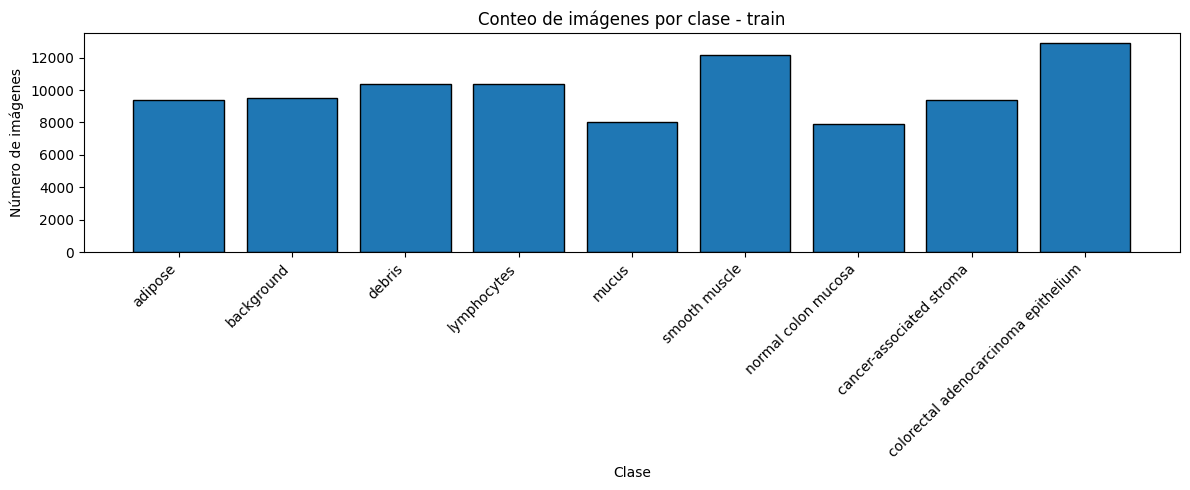

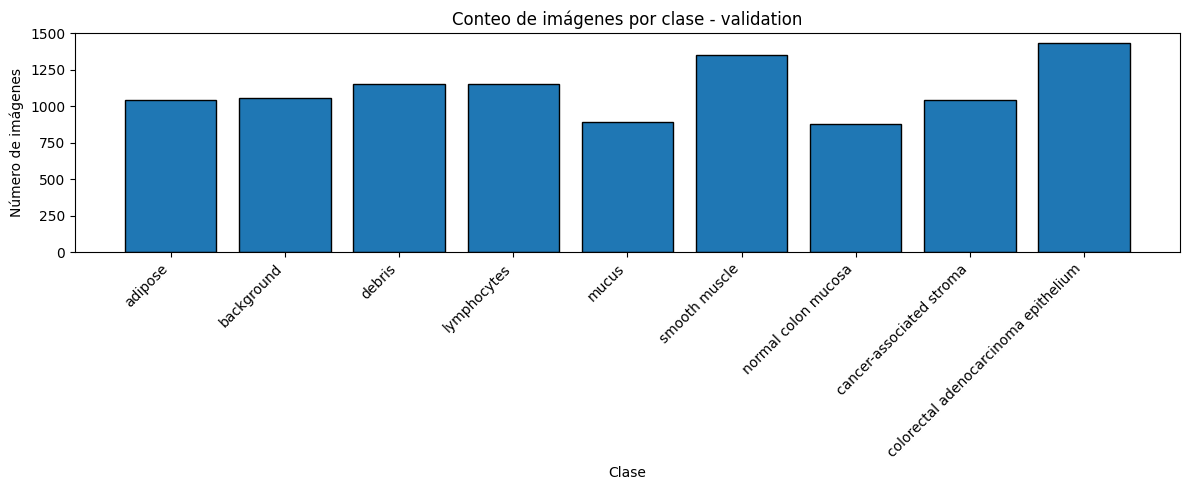

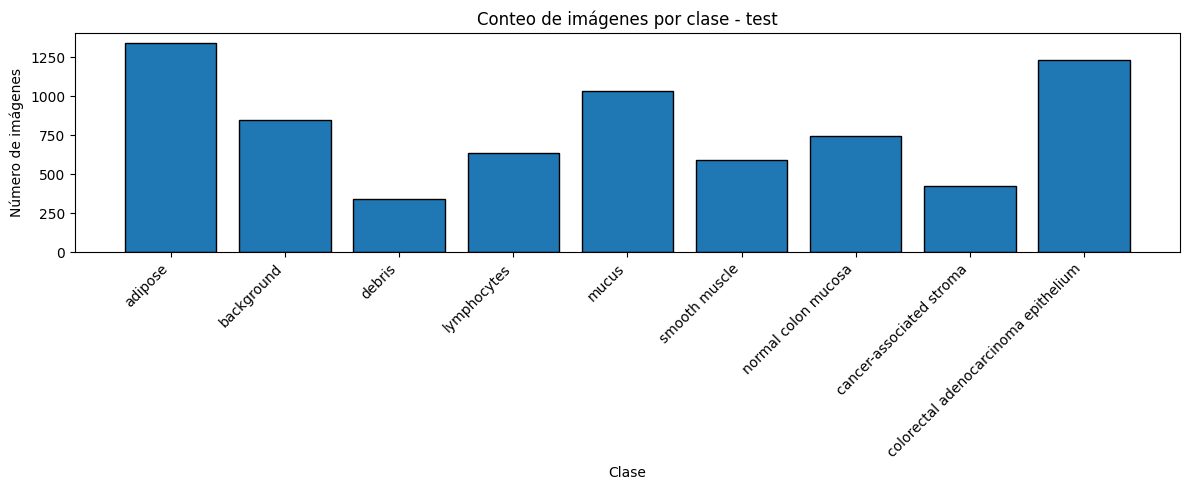

In [8]:
for split_name in ["train", "validation", "test"]:
    split_data = class_distribution_df[class_distribution_df["split"] == split_name]

    plt.figure(figsize=(12, 5))
    plt.bar(split_data["class_name"], split_data["count"], edgecolor="black")
    plt.title(f"Conteo de imágenes por clase - {split_name}")
    plt.xlabel("Clase")
    plt.ylabel("Número de imágenes")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## Gráficos de comparación porcentual entre splits


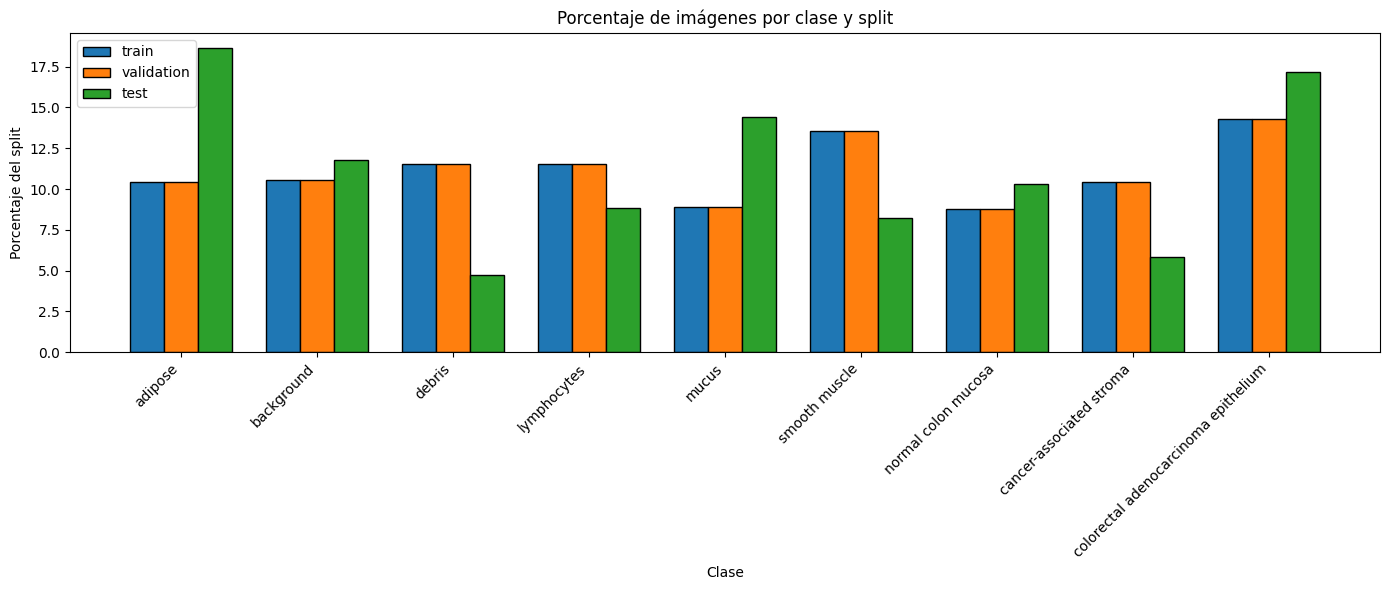

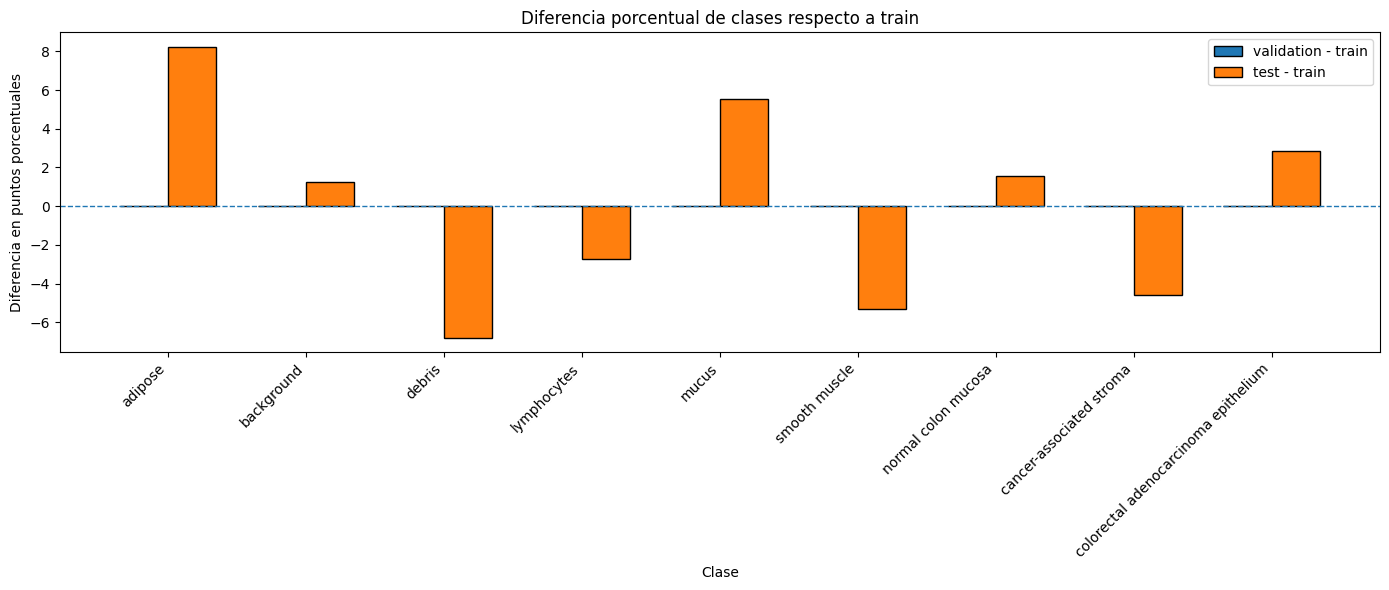

In [9]:
x = np.arange(len(class_percentage_pivot["class_name"]))
width = 0.25

plt.figure(figsize=(14, 6))
plt.bar(x - width, class_percentage_pivot["train"], width, label="train", edgecolor="black")
plt.bar(x, class_percentage_pivot["validation"], width, label="validation", edgecolor="black")
plt.bar(x + width, class_percentage_pivot["test"], width, label="test", edgecolor="black")
plt.title("Porcentaje de imágenes por clase y split")
plt.xlabel("Clase")
plt.ylabel("Porcentaje del split")
plt.xticks(x, class_percentage_pivot["class_name"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

x = np.arange(len(split_difference_df["class_name"]))
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar(x - width / 2, split_difference_df["validation_minus_train"], width, label="validation - train", edgecolor="black")
plt.bar(x + width / 2, split_difference_df["test_minus_train"], width, label="test - train", edgecolor="black")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Diferencia porcentual de clases respecto a train")
plt.xlabel("Clase")
plt.ylabel("Diferencia en puntos porcentuales")
plt.xticks(x, split_difference_df["class_name"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


**Conclusión Fase 3.** Esta fase entrega la evidencia necesaria para justificar métricas más robustas que accuracy. Si las clases no están perfectamente equilibradas, el baseline debe reportar al menos accuracy y macro-F1, idealmente acompañado de matriz de confusión.


# Fase 4 - Visualización cualitativa de imágenes

Objetivo: observar muestras reales por clase y por split antes de construir estadísticas de píxeles. La tabla de cobertura se revisa antes de graficar para asegurar que las muestras visuales sean representativas.


## Tabla de cobertura visual por clase y split


In [10]:
visual_coverage_df = class_distribution_df.pivot(
    index=["class_id", "class_name"],
    columns="split",
    values="count"
).reset_index()

visual_coverage_df["min_available_across_splits"] = visual_coverage_df[
    ["train", "validation", "test"]
].min(axis=1)

display(visual_coverage_df)


split,class_id,class_name,test,train,validation,min_available_across_splits
0,0,adipose,1338,9366,1041,1041
1,1,background,847,9509,1057,847
2,2,debris,339,10360,1152,339
3,3,lymphocytes,634,10401,1156,634
4,4,mucus,1035,8006,890,890
5,5,smooth muscle,592,12182,1354,592
6,6,normal colon mucosa,741,7886,877,741
7,7,cancer-associated stroma,421,9401,1045,421
8,8,colorectal adenocarcinoma epithelium,1233,12885,1432,1233


## Funciones auxiliares de visualización


In [11]:
def sample_indices_by_class(dataset, class_id, n_samples=3, seed=42):
    labels = dataset.labels.reshape(-1).astype(int)
    candidate_indices = np.where(labels == class_id)[0]
    rng = np.random.default_rng(seed)
    selected = rng.choice(
        candidate_indices,
        size=min(n_samples, len(candidate_indices)),
        replace=False,
    )
    return selected


def plot_all_classes_across_splits(datasets, class_id_to_name, seed=42):
    class_ids = sorted(class_id_to_name.keys())
    split_names = ["train", "validation", "test"]

    fig, axes = plt.subplots(
        nrows=len(class_ids),
        ncols=len(split_names),
        figsize=(9, 2.1 * len(class_ids)),
    )

    for row_idx, class_id in enumerate(class_ids):
        for col_idx, split_name in enumerate(split_names):
            dataset = datasets[split_name]
            selected_idx = sample_indices_by_class(dataset, class_id, n_samples=1, seed=seed + row_idx + col_idx)[0]
            image = dataset.imgs[selected_idx]

            ax = axes[row_idx, col_idx]
            ax.imshow(image)
            ax.axis("off")
            if row_idx == 0:
                ax.set_title(split_name)
            if col_idx == 0:
                ax.set_ylabel(f"{class_id}: {class_id_to_name[class_id]}", rotation=0, ha="right", va="center")

    fig.suptitle("Muestra visual por clase y split", y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_class_across_splits(datasets, class_id, class_id_to_name, n_samples=4, seed=42):
    split_names = ["train", "validation", "test"]
    fig, axes = plt.subplots(
        nrows=len(split_names),
        ncols=n_samples,
        figsize=(2.2 * n_samples, 6),
    )

    for row_idx, split_name in enumerate(split_names):
        dataset = datasets[split_name]
        selected_indices = sample_indices_by_class(dataset, class_id, n_samples=n_samples, seed=seed + row_idx)

        for col_idx in range(n_samples):
            ax = axes[row_idx, col_idx]
            ax.imshow(dataset.imgs[selected_indices[col_idx]])
            ax.axis("off")
            if col_idx == 0:
                ax.set_ylabel(split_name, rotation=0, ha="right", va="center")

    fig.suptitle(f"Clase {class_id}: {class_id_to_name[class_id]} por split", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


## Muestras representativas


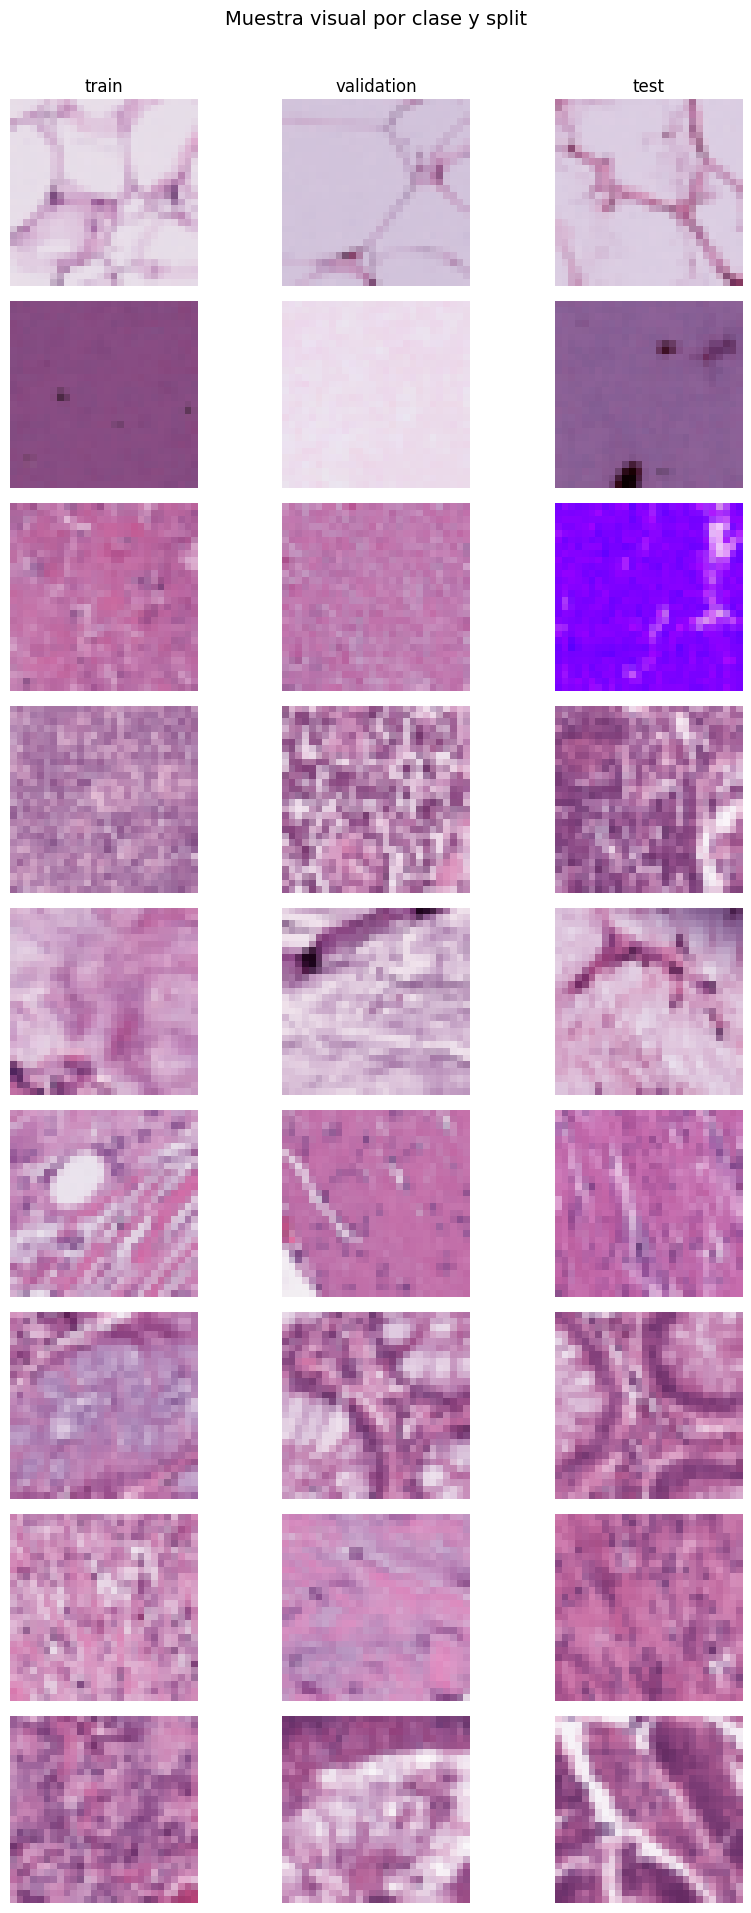

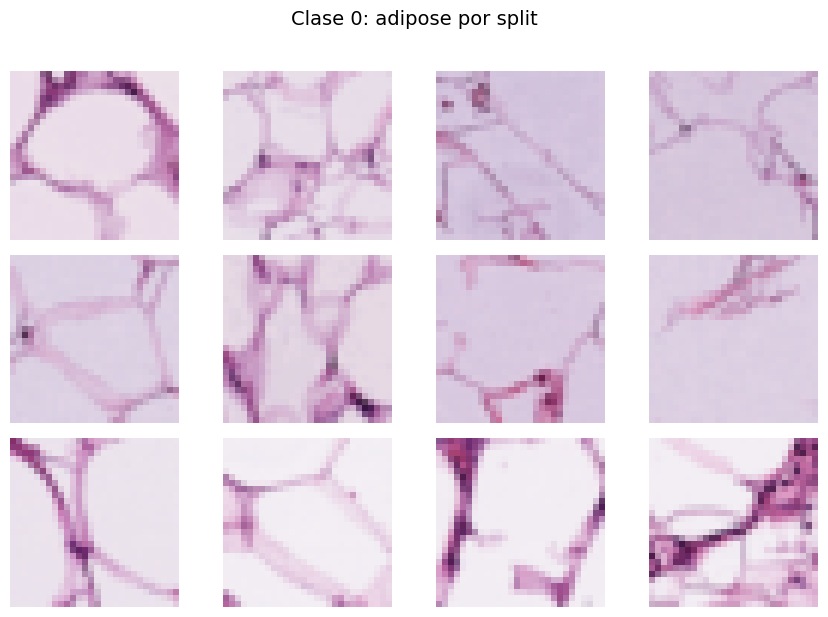

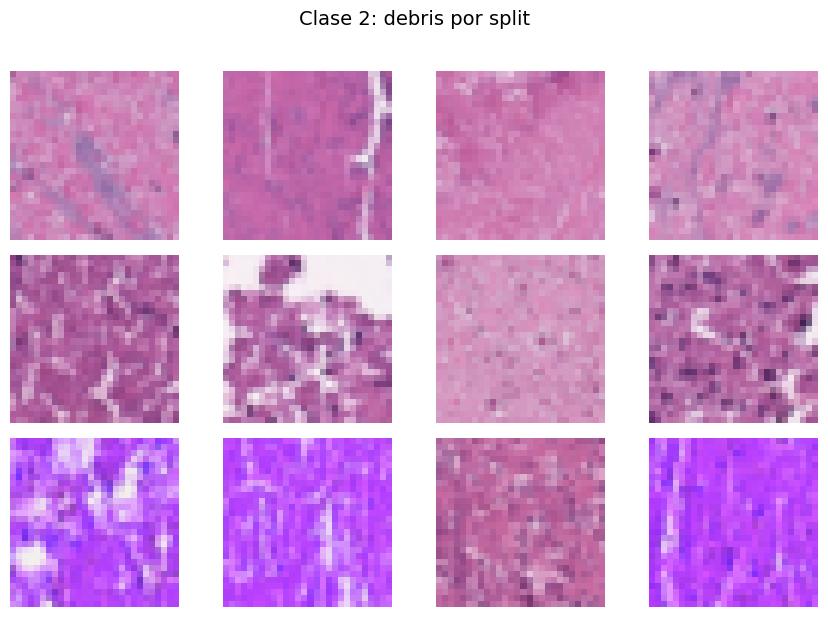

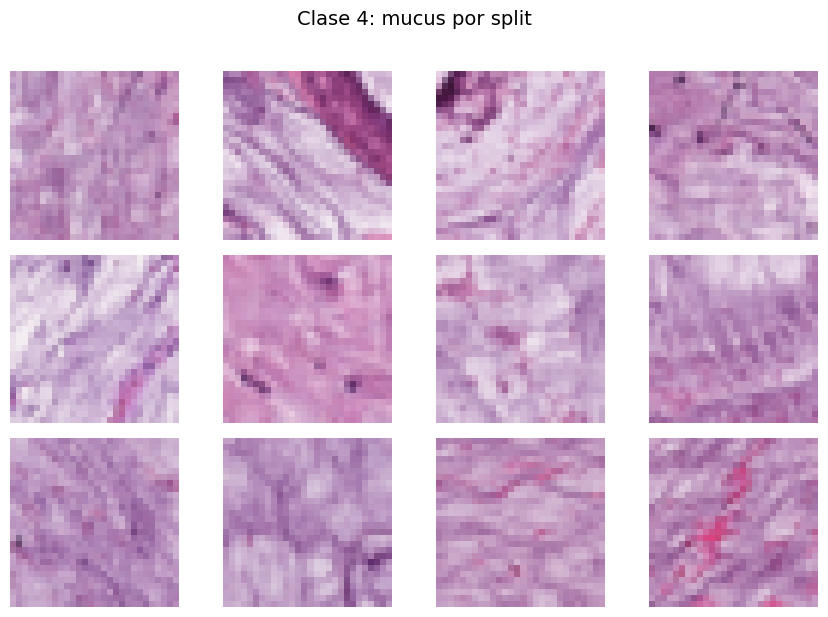

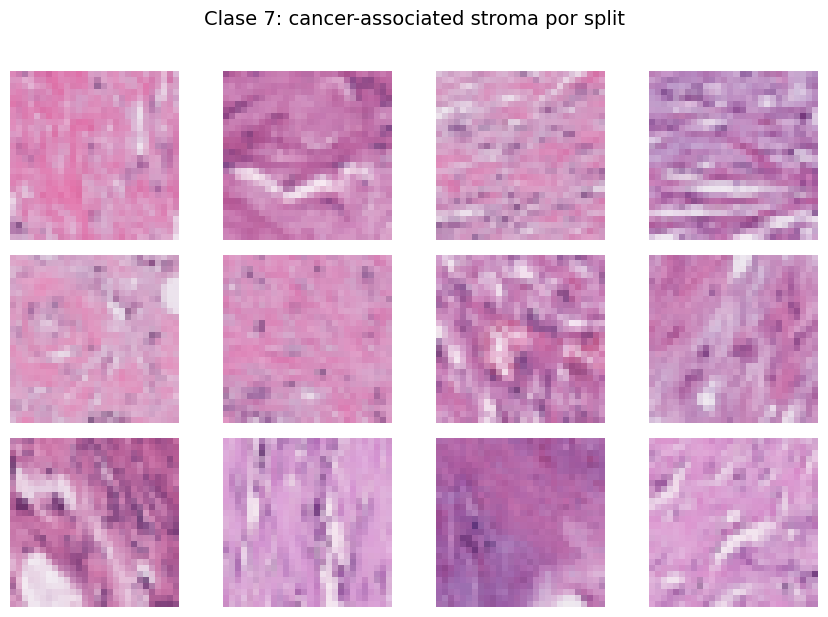

In [12]:
plot_all_classes_across_splits(datasets, class_id_to_name, seed=SEED)

selected_classes_for_visual_review = [0, 2, 4, 7]
for class_id in selected_classes_for_visual_review:
    plot_class_across_splits(
        datasets=datasets,
        class_id=class_id,
        class_id_to_name=class_id_to_name,
        n_samples=4,
        seed=SEED,
    )


**Conclusión Fase 4.** La inspección visual cumple el requisito de mostrar muestras del dataset y permite detectar variabilidad morfológica entre clases. Esta evidencia se debe usar en la presentación, pero sin saturar con mosaicos repetidos.


# Fase 5 - Estadísticas globales de píxeles y canales RGB

Objetivo: calcular medias y desviaciones RGB por split para definir normalización y revisar diferencias globales antes de entrenar modelos.


## Tablas globales RGB y parámetros de normalización


In [13]:
def compute_global_rgb_statistics(dataset, split_name):
    images = dataset.imgs.astype(np.float32)
    channel_names = ["R", "G", "B"]
    rows = []

    for channel_idx, channel_name in enumerate(channel_names):
        values = images[:, :, :, channel_idx].reshape(-1)
        rows.append({
            "split": split_name,
            "channel": channel_name,
            "min": values.min(),
            "p01": np.percentile(values, 1),
            "mean": values.mean(),
            "median": np.median(values),
            "p99": np.percentile(values, 99),
            "max": values.max(),
            "std": values.std(),
        })

    return pd.DataFrame(rows)

global_rgb_stats_df = pd.concat([
    compute_global_rgb_statistics(dataset, split_name)
    for split_name, dataset in datasets.items()
], ignore_index=True)

rgb_mean_pivot = global_rgb_stats_df.pivot(index="split", columns="channel", values="mean").reset_index()
rgb_std_pivot = global_rgb_stats_df.pivot(index="split", columns="channel", values="std").reset_index()

rgb_mean_display = rgb_mean_pivot.copy()
rgb_std_display = rgb_std_pivot.copy()
for df in [rgb_mean_display, rgb_std_display]:
    for channel in ["R", "G", "B"]:
        df[channel] = df[channel].round(2)

train_rgb_mean_255 = rgb_mean_pivot[rgb_mean_pivot["split"] == "train"][["R", "G", "B"]].iloc[0].to_numpy()
train_rgb_std_255 = rgb_std_pivot[rgb_std_pivot["split"] == "train"][["R", "G", "B"]].iloc[0].to_numpy()

normalization_stats_df = pd.DataFrame({
    "channel": ["R", "G", "B"],
    "mean_0_255": train_rgb_mean_255,
    "std_0_255": train_rgb_std_255,
    "mean_0_1": train_rgb_mean_255 / 255.0,
    "std_0_1": train_rgb_std_255 / 255.0,
}).round(4)

print("Medias RGB por split")
display(rgb_mean_display)
print("Desviaciones estándar RGB por split")
display(rgb_std_display)
print("Parámetros recomendados de normalización basados solo en train")
display(normalization_stats_df)


Medias RGB por split


channel,split,B,G,R
0,test,180.850006,136.520004,185.350006
1,train,179.990005,135.910004,188.839996
2,validation,180.270004,136.300003,189.080002


Desviaciones estándar RGB por split


channel,split,B,G,R
0,test,38.549999,53.48,37.520000
1,train,31.730000,45.07,31.540001
2,validation,31.709999,45.18,31.400000


Parámetros recomendados de normalización basados solo en train


,channel,mean_0_255,std_0_255,mean_0_1,std_0_1
0,R,188.839005,31.539000,0.7405,0.1237
1,G,135.910507,45.074402,0.5330,0.1768
2,B,179.986404,31.729799,0.7058,0.1244


## Gráficos globales de media y desviación estándar RGB


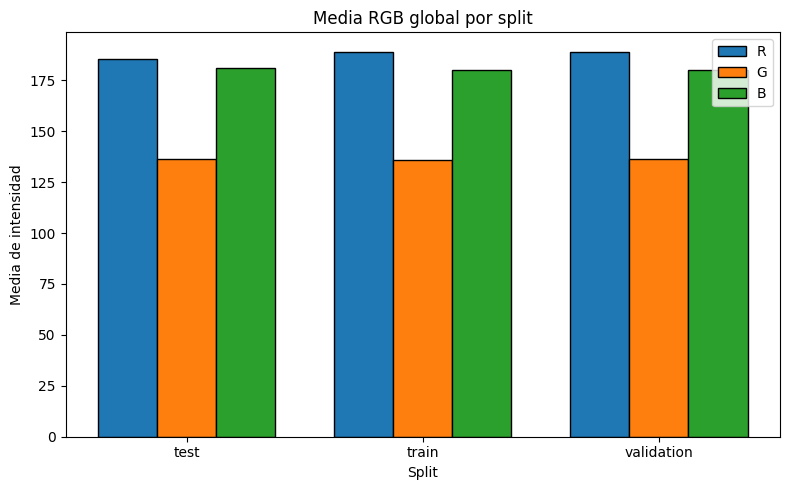

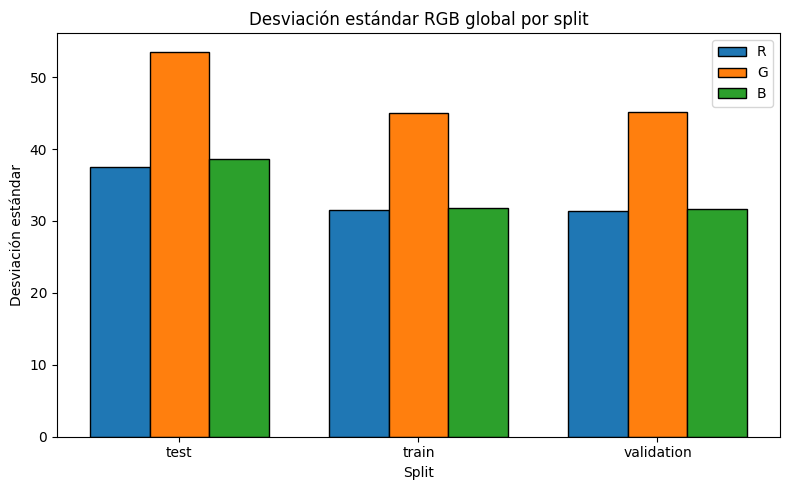

In [14]:
x = np.arange(len(rgb_mean_pivot["split"]))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, rgb_mean_pivot["R"], width, label="R", edgecolor="black")
plt.bar(x, rgb_mean_pivot["G"], width, label="G", edgecolor="black")
plt.bar(x + width, rgb_mean_pivot["B"], width, label="B", edgecolor="black")
plt.title("Media RGB global por split")
plt.xlabel("Split")
plt.ylabel("Media de intensidad")
plt.xticks(x, rgb_mean_pivot["split"])
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(x - width, rgb_std_pivot["R"], width, label="R", edgecolor="black")
plt.bar(x, rgb_std_pivot["G"], width, label="G", edgecolor="black")
plt.bar(x + width, rgb_std_pivot["B"], width, label="B", edgecolor="black")
plt.title("Desviación estándar RGB global por split")
plt.xlabel("Split")
plt.ylabel("Desviación estándar")
plt.xticks(x, rgb_std_pivot["split"])
plt.legend()
plt.tight_layout()
plt.show()


## Tabla de diferencias RGB respecto a train


In [15]:
rgb_difference_rows = []
train_means = rgb_mean_pivot[rgb_mean_pivot["split"] == "train"][["R", "G", "B"]].iloc[0]
train_stds = rgb_std_pivot[rgb_std_pivot["split"] == "train"][["R", "G", "B"]].iloc[0]

for split_name in ["validation", "test"]:
    split_means = rgb_mean_pivot[rgb_mean_pivot["split"] == split_name][["R", "G", "B"]].iloc[0]
    split_stds = rgb_std_pivot[rgb_std_pivot["split"] == split_name][["R", "G", "B"]].iloc[0]

    for channel in ["R", "G", "B"]:
        rgb_difference_rows.append({
            "split": split_name,
            "channel": channel,
            "mean_train": train_means[channel],
            "mean_split": split_means[channel],
            "mean_difference": split_means[channel] - train_means[channel],
            "std_train": train_stds[channel],
            "std_split": split_stds[channel],
            "std_difference": split_stds[channel] - train_stds[channel],
        })

rgb_difference_df = pd.DataFrame(rgb_difference_rows).round(3)
display(rgb_difference_df)


,split,channel,mean_train,mean_split,mean_difference,std_train,std_split,std_difference
0,validation,R,188.839005,189.074997,0.236,31.539000,31.400000,-0.139
1,validation,G,135.910004,136.304001,0.393,45.074001,45.181999,0.107
2,validation,B,179.985992,180.270004,0.284,31.730000,31.712999,-0.017
3,test,R,188.839005,185.350006,-3.489,31.539000,37.521000,5.982
4,test,G,135.910004,136.518997,0.609,45.074001,53.477001,8.402
5,test,B,179.985992,180.852005,0.865,31.730000,38.550999,6.821


**Conclusión Fase 5.** La normalización debe calcularse con estadísticas del split de entrenamiento para evitar fuga de información. Las diferencias RGB entre splits permiten anticipar si existe un cambio global relevante de color o contraste.


# Fase 6 - Estadísticas RGB por clase

Objetivo: identificar si algunas clases presentan perfiles cromáticos propios. Esto ayuda a interpretar qué señales podría explotar una CNN y si conviene aplicar augmentations moderadas de color.


## Tablas RGB por clase en train


In [16]:
def compute_rgb_statistics_by_class(dataset, split_name, class_id_to_name):
    images = dataset.imgs.astype(np.float32)
    labels = dataset.labels.reshape(-1).astype(int)
    channel_names = ["R", "G", "B"]
    rows = []

    for class_id, class_name in class_id_to_name.items():
        class_images = images[labels == class_id]
        for channel_idx, channel_name in enumerate(channel_names):
            values = class_images[:, :, :, channel_idx].reshape(-1)
            rows.append({
                "split": split_name,
                "class_id": class_id,
                "class_name": class_name,
                "channel": channel_name,
                "mean": values.mean(),
                "std": values.std(),
            })

    return pd.DataFrame(rows)

class_rgb_stats_df = pd.concat([
    compute_rgb_statistics_by_class(dataset, split_name, class_id_to_name)
    for split_name, dataset in datasets.items()
], ignore_index=True)

train_class_rgb_mean = class_rgb_stats_df[class_rgb_stats_df["split"] == "train"].pivot(
    index=["class_id", "class_name"], columns="channel", values="mean"
).reset_index()

train_class_rgb_std = class_rgb_stats_df[class_rgb_stats_df["split"] == "train"].pivot(
    index=["class_id", "class_name"], columns="channel", values="std"
).reset_index()

for df in [train_class_rgb_mean, train_class_rgb_std]:
    for channel in ["R", "G", "B"]:
        df[channel] = df[channel].round(2)

print("Medias RGB por clase en train")
display(train_class_rgb_mean)
print("Desviaciones estándar RGB por clase en train")
display(train_class_rgb_std)


Medias RGB por clase en train


channel,class_id,class_name,B,G,R
0,0,adipose,215.470001,193.059998,214.289993
1,1,background,157.710007,112.330002,156.759995
2,2,debris,177.550003,125.230003,192.449997
3,3,lymphocytes,169.020004,125.470001,176.289993
4,4,mucus,192.110001,154.070007,196.559998
5,5,smooth muscle,184.820007,133.600006,199.929993
6,6,normal colon mucosa,176.839996,133.750000,186.490005
7,7,cancer-associated stroma,182.520004,133.960007,197.070007
8,8,colorectal adenocarcinoma epithelium,169.410004,122.440002,181.380005


Desviaciones estándar RGB por clase en train


channel,class_id,class_name,B,G,R
0,0,adipose,20.870001,29.670000,17.900000
1,1,background,46.990002,61.970001,48.060001
2,2,debris,24.020000,35.150002,24.090000
3,3,lymphocytes,24.320000,33.389999,25.580000
4,4,mucus,25.830000,37.299999,23.620001
5,5,smooth muscle,22.820000,38.160000,21.670000
6,6,normal colon mucosa,30.830000,42.779999,29.370001
7,7,cancer-associated stroma,18.750000,27.200001,19.309999
8,8,colorectal adenocarcinoma epithelium,27.930000,39.509998,28.190001


## Gráficos RGB por clase


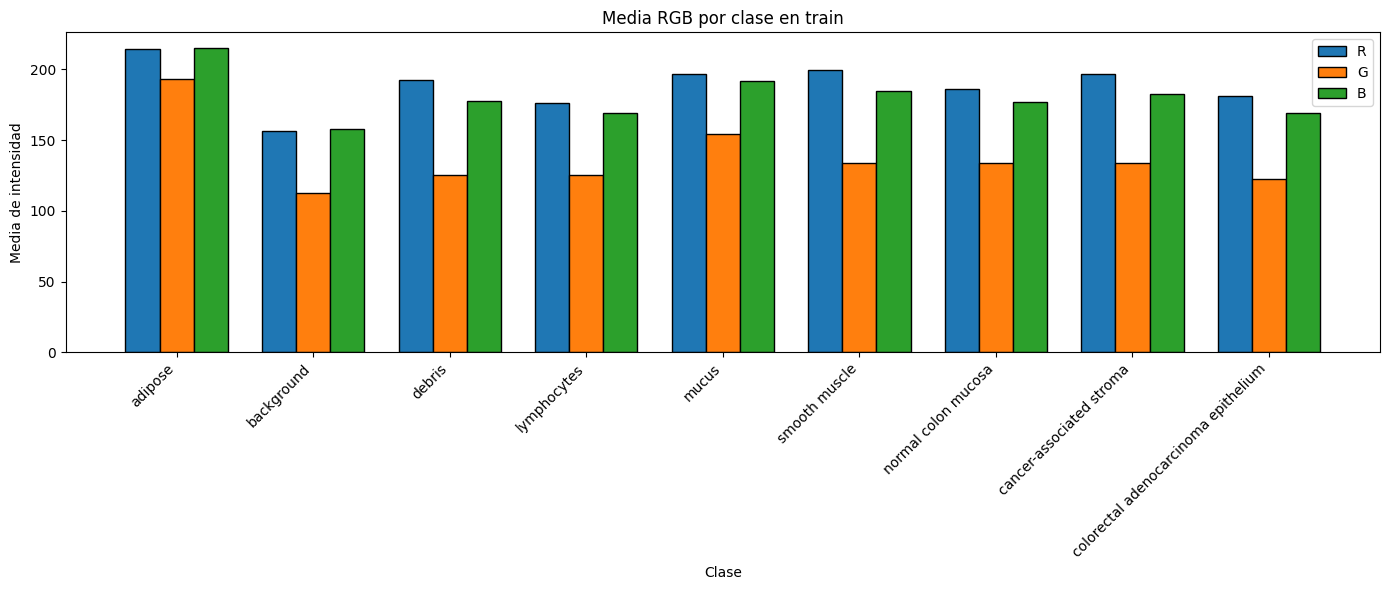

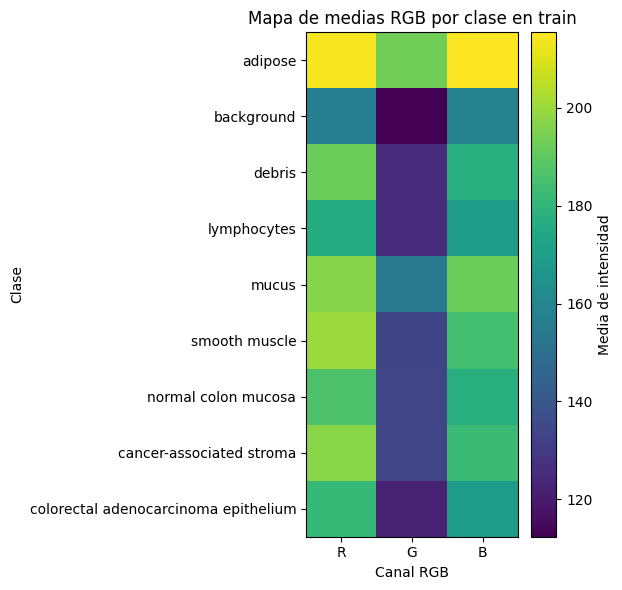

In [17]:
x = np.arange(len(train_class_rgb_mean["class_name"]))
width = 0.25

plt.figure(figsize=(14, 6))
plt.bar(x - width, train_class_rgb_mean["R"], width, label="R", edgecolor="black")
plt.bar(x, train_class_rgb_mean["G"], width, label="G", edgecolor="black")
plt.bar(x + width, train_class_rgb_mean["B"], width, label="B", edgecolor="black")
plt.title("Media RGB por clase en train")
plt.xlabel("Clase")
plt.ylabel("Media de intensidad")
plt.xticks(x, train_class_rgb_mean["class_name"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

heatmap_data = train_class_rgb_mean[["R", "G", "B"]].to_numpy()
plt.figure(figsize=(6, 6))
plt.imshow(heatmap_data, aspect="auto")
plt.title("Mapa de medias RGB por clase en train")
plt.xlabel("Canal RGB")
plt.ylabel("Clase")
plt.xticks(np.arange(3), ["R", "G", "B"])
plt.yticks(np.arange(len(train_class_rgb_mean["class_name"])), train_class_rgb_mean["class_name"])
plt.colorbar(label="Media de intensidad")
plt.tight_layout()
plt.show()


## Tabla de cambio cromático por clase entre train y test


In [18]:
class_rgb_mean_pivot = class_rgb_stats_df.pivot(
    index=["class_id", "class_name", "channel"],
    columns="split",
    values="mean",
).reset_index()

class_rgb_std_pivot = class_rgb_stats_df.pivot(
    index=["class_id", "class_name", "channel"],
    columns="split",
    values="std",
).reset_index()

class_rgb_mean_pivot["abs_test_minus_train_mean"] = (
    class_rgb_mean_pivot["test"] - class_rgb_mean_pivot["train"]
).abs()
class_rgb_std_pivot["abs_test_minus_train_std"] = (
    class_rgb_std_pivot["test"] - class_rgb_std_pivot["train"]
).abs()

class_rgb_shift_summary = class_rgb_mean_pivot.groupby(["class_id", "class_name"]).agg(
    abs_test_minus_train_mean=("abs_test_minus_train_mean", "mean")
).reset_index().merge(
    class_rgb_std_pivot.groupby(["class_id", "class_name"]).agg(
        abs_test_minus_train_std=("abs_test_minus_train_std", "mean")
    ).reset_index(),
    on=["class_id", "class_name"],
)

class_rgb_shift_summary["combined_rgb_shift_score"] = (
    class_rgb_shift_summary["abs_test_minus_train_mean"] +
    class_rgb_shift_summary["abs_test_minus_train_std"]
)

class_rgb_shift_summary = class_rgb_shift_summary.sort_values(
    "combined_rgb_shift_score", ascending=False
).reset_index(drop=True)

display(class_rgb_shift_summary.round(3))


,class_id,class_name,abs_test_minus_train_mean,abs_test_minus_train_std,combined_rgb_shift_score
0,1,background,30.091000,38.166,68.257004
1,2,debris,21.684999,8.116,29.801001
2,5,smooth muscle,12.522000,4.899,17.421000
3,0,adipose,9.090000,6.135,15.225000
4,3,lymphocytes,5.787000,7.618,13.405000
5,8,colorectal adenocarcinoma epithelium,5.819000,6.812,12.631000
6,7,cancer-associated stroma,7.096000,4.778,11.874000
7,4,mucus,3.523000,4.630,8.153000
8,6,normal colon mucosa,1.986000,3.053,5.039000


## Gráfico de cambio cromático agregado por clase


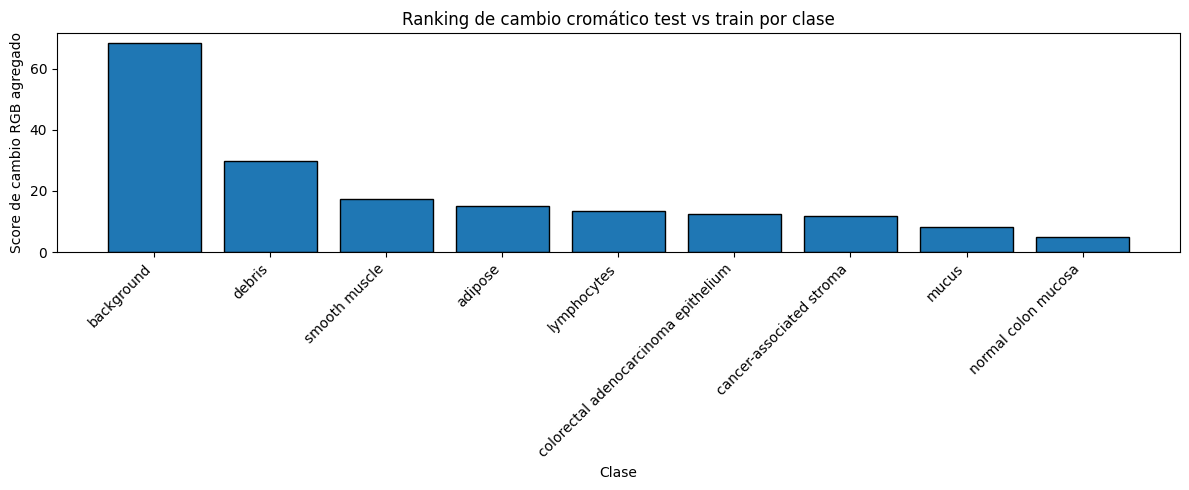

In [19]:
plt.figure(figsize=(12, 5))
plt.bar(
    class_rgb_shift_summary["class_name"],
    class_rgb_shift_summary["combined_rgb_shift_score"],
    edgecolor="black",
)
plt.title("Ranking de cambio cromático test vs train por clase")
plt.xlabel("Clase")
plt.ylabel("Score de cambio RGB agregado")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Conclusión Fase 6.** Las estadísticas por clase permiten distinguir variabilidad esperable del tejido frente a posibles cambios de color entre splits. Para el baseline conviene usar normalización desde train y augmentations conservadoras, evitando transformaciones que alteren demasiado la señal histológica.


# Fase 7 - Comparación entre splits y posible shift

Objetivo: evaluar si validation y test se parecen razonablemente a train en distribución de clases y distribución RGB. Esta fase conecta directamente con la confiabilidad del hold-out.


## Tabla de shift en distribución de clases


In [20]:
def compute_class_distribution_shift(class_percentage_pivot):
    rows = []
    for split_name in ["validation", "test"]:
        diff = class_percentage_pivot[split_name] - class_percentage_pivot["train"]
        rows.append({
            "comparison": f"{split_name}_vs_train",
            "mean_abs_difference_pp": diff.abs().mean(),
            "max_abs_difference_pp": diff.abs().max(),
            "total_variation_distance": 0.5 * (diff.abs() / 100).sum(),
        })
    return pd.DataFrame(rows)

class_distribution_shift_df = compute_class_distribution_shift(class_percentage_pivot).round(4)
display(class_distribution_shift_df)
display(split_difference_df)


,comparison,mean_abs_difference_pp,max_abs_difference_pp,total_variation_distance
0,validation_vs_train,0.0044,0.01,0.0002
1,test_vs_train,4.3100,8.23,0.1940


split,class_id,class_name,validation_minus_train,test_minus_train
0,0,adipose,0.00,8.23
1,1,background,0.00,1.23
2,2,debris,0.01,-6.79
3,3,lymphocytes,0.00,-2.73
4,4,mucus,0.00,5.52
5,5,smooth muscle,-0.01,-5.29
6,6,normal colon mucosa,0.01,1.56
7,7,cancer-associated stroma,0.00,-4.59
8,8,colorectal adenocarcinoma epithelium,-0.01,2.85


## Gráfico de diferencias porcentuales respecto a train


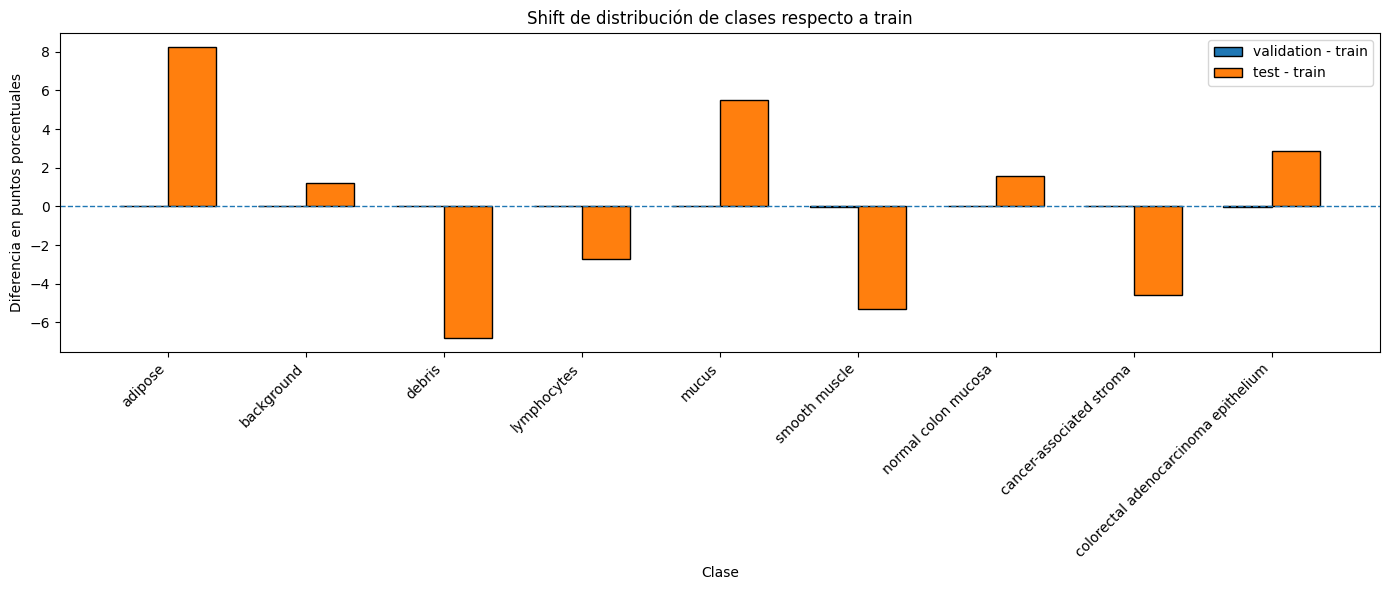

In [21]:
x = np.arange(len(split_difference_df["class_name"]))
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar(x - width / 2, split_difference_df["validation_minus_train"], width, label="validation - train", edgecolor="black")
plt.bar(x + width / 2, split_difference_df["test_minus_train"], width, label="test - train", edgecolor="black")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Shift de distribución de clases respecto a train")
plt.xlabel("Clase")
plt.ylabel("Diferencia en puntos porcentuales")
plt.xticks(x, split_difference_df["class_name"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


## Tabla y gráfico de divergencia Jensen-Shannon por canal RGB


,comparison,channel,jensen_shannon_divergence
0,validation_vs_train,R,0.000195
1,validation_vs_train,G,0.000230
2,validation_vs_train,B,0.000221
3,test_vs_train,R,0.056287
4,test_vs_train,G,0.053513
5,test_vs_train,B,0.056842


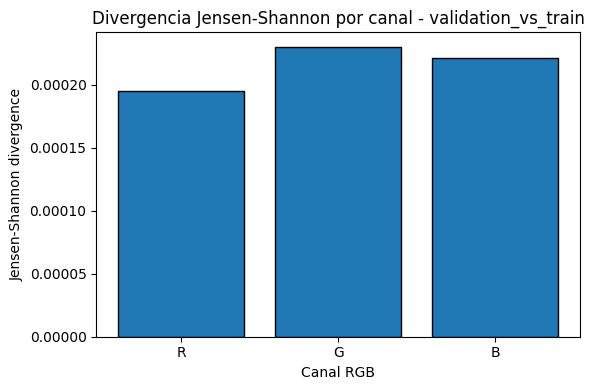

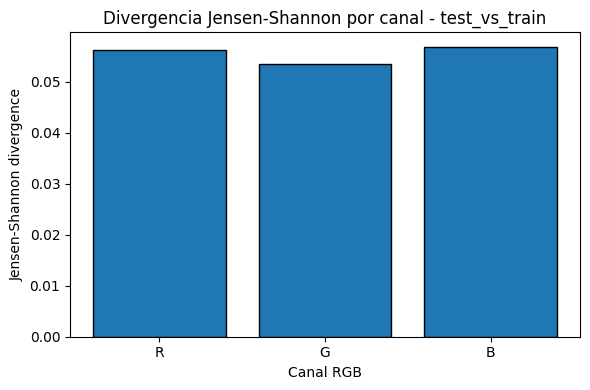

In [22]:
def compute_js_divergence_from_histograms(values_a, values_b, bins=256, value_range=(0, 255)):
    hist_a, _ = np.histogram(values_a, bins=bins, range=value_range)
    hist_b, _ = np.histogram(values_b, bins=bins, range=value_range)

    p = hist_a.astype(float)
    q = hist_b.astype(float)
    p = p / p.sum()
    q = q / q.sum()

    eps = 1e-12
    p = p + eps
    q = q + eps
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)

    kl_pm = np.sum(p * np.log2(p / m))
    kl_qm = np.sum(q * np.log2(q / m))
    return 0.5 * (kl_pm + kl_qm)

channel_names = ["R", "G", "B"]
js_rows = []
train_images = train_dataset.imgs

for split_name in ["validation", "test"]:
    split_images = datasets[split_name].imgs
    for channel_idx, channel_name in enumerate(channel_names):
        js_rows.append({
            "comparison": f"{split_name}_vs_train",
            "channel": channel_name,
            "jensen_shannon_divergence": compute_js_divergence_from_histograms(
                train_images[:, :, :, channel_idx].reshape(-1),
                split_images[:, :, :, channel_idx].reshape(-1),
            ),
        })

channel_jsd_df = pd.DataFrame(js_rows).round(6)
display(channel_jsd_df)

for comparison in channel_jsd_df["comparison"].unique():
    comparison_df = channel_jsd_df[channel_jsd_df["comparison"] == comparison]
    plt.figure(figsize=(6, 4))
    plt.bar(comparison_df["channel"], comparison_df["jensen_shannon_divergence"], edgecolor="black")
    plt.title(f"Divergencia Jensen-Shannon por canal - {comparison}")
    plt.xlabel("Canal RGB")
    plt.ylabel("Jensen-Shannon divergence")
    plt.tight_layout()
    plt.show()


**Conclusión Fase 7.** Si las diferencias entre splits son pequeñas, el hold-out oficial es una base razonable para validación. Si alguna clase o canal muestra variación relevante, debe mencionarse como riesgo al interpretar resultados.


# Fase 8 - Auditoría de calidad visual

Objetivo: detectar imágenes extremas por intensidad o variabilidad. No se eliminan datos automáticamente; la auditoría sirve para documentar riesgos y revisar ejemplos.


## Tablas de calidad visual y flags exploratorios


In [23]:
def compute_image_quality_metrics(dataset, split_name, class_id_to_name):
    images = dataset.imgs.astype(np.float32)
    labels = dataset.labels.reshape(-1).astype(int)
    rows = []

    for idx in range(images.shape[0]):
        image = images[idx]
        gray_like = image.mean(axis=2)
        rows.append({
            "split": split_name,
            "image_index": idx,
            "class_id": labels[idx],
            "class_name": class_id_to_name[labels[idx]],
            "mean_intensity": gray_like.mean(),
            "std_intensity": gray_like.std(),
            "p01_intensity": np.percentile(gray_like, 1),
            "p99_intensity": np.percentile(gray_like, 99),
        })

    return pd.DataFrame(rows)

image_quality_df = pd.concat([
    compute_image_quality_metrics(dataset, split_name, class_id_to_name)
    for split_name, dataset in datasets.items()
], ignore_index=True)

quality_summary_by_split = image_quality_df.groupby("split").agg(
    num_images=("image_index", "count"),
    mean_intensity_mean=("mean_intensity", "mean"),
    mean_intensity_std=("mean_intensity", "std"),
    std_intensity_mean=("std_intensity", "mean"),
    std_intensity_std=("std_intensity", "std"),
).reset_index().round(3)

quality_thresholds = {
    "very_dark_mean": image_quality_df["mean_intensity"].quantile(0.01),
    "very_bright_mean": image_quality_df["mean_intensity"].quantile(0.99),
    "very_low_std": image_quality_df["std_intensity"].quantile(0.01),
    "very_high_std": image_quality_df["std_intensity"].quantile(0.99),
}
quality_thresholds_df = pd.DataFrame([quality_thresholds]).round(3)

image_quality_flags_df = image_quality_df.copy()
image_quality_flags_df["flag_very_dark"] = image_quality_flags_df["mean_intensity"] <= quality_thresholds["very_dark_mean"]
image_quality_flags_df["flag_very_bright"] = image_quality_flags_df["mean_intensity"] >= quality_thresholds["very_bright_mean"]
image_quality_flags_df["flag_low_variability"] = image_quality_flags_df["std_intensity"] <= quality_thresholds["very_low_std"]
image_quality_flags_df["flag_high_variability"] = image_quality_flags_df["std_intensity"] >= quality_thresholds["very_high_std"]

flag_columns = [
    "flag_very_dark",
    "flag_very_bright",
    "flag_low_variability",
    "flag_high_variability",
]
image_quality_flags_df["num_flags"] = image_quality_flags_df[flag_columns].sum(axis=1)

quality_flags_by_split = image_quality_flags_df.groupby("split")[flag_columns + ["num_flags"]].sum().reset_index()
quality_flags_by_class = image_quality_flags_df.groupby(["class_id", "class_name"])[flag_columns + ["num_flags"]].sum().reset_index()

print("Resumen de calidad por split")
display(quality_summary_by_split)
print("Umbrales exploratorios")
display(quality_thresholds_df)
print("Flags por split")
display(quality_flags_by_split)
print("Flags por clase")
display(quality_flags_by_class)


Resumen de calidad por split


,split,num_images,mean_intensity_mean,mean_intensity_std,std_intensity_mean,std_intensity_std
0,test,7180,167.574005,32.804001,22.773001,11.747
1,train,89996,168.244995,26.680000,20.780001,9.981
2,validation,10004,168.550003,26.634001,20.895000,9.861


Umbrales exploratorios


,very_dark_mean,very_bright_mean,very_low_std,very_high_std
0,96.465,231.298,0.921,46.761


Flags por split


,split,flag_very_dark,flag_very_bright,flag_low_variability,flag_high_variability,num_flags
0,test,14,25,2,236,277
1,train,965,949,944,773,3631
2,validation,93,99,126,63,381


Flags por clase


,class_id,class_name,flag_very_dark,flag_very_bright,flag_low_variability,flag_high_variability,num_flags
0,0,adipose,0,31,4,47,82
1,1,background,1061,980,1060,105,3206
2,2,debris,10,19,4,147,180
3,3,lymphocytes,0,0,0,18,18
4,4,mucus,1,6,0,116,123
5,5,smooth muscle,0,34,4,42,80
6,6,normal colon mucosa,0,1,0,32,33
7,7,cancer-associated stroma,0,0,0,0,0
8,8,colorectal adenocarcinoma epithelium,0,2,0,565,567


## Histogramas de intensidad y variabilidad


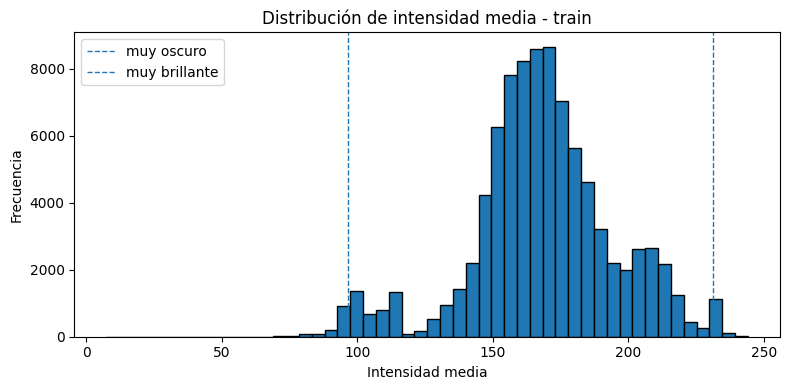

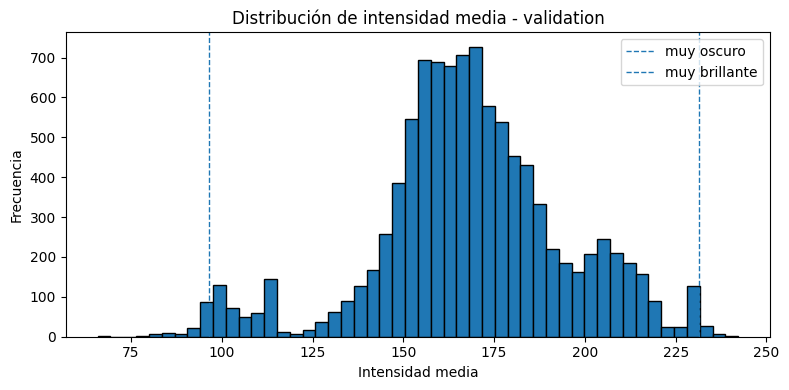

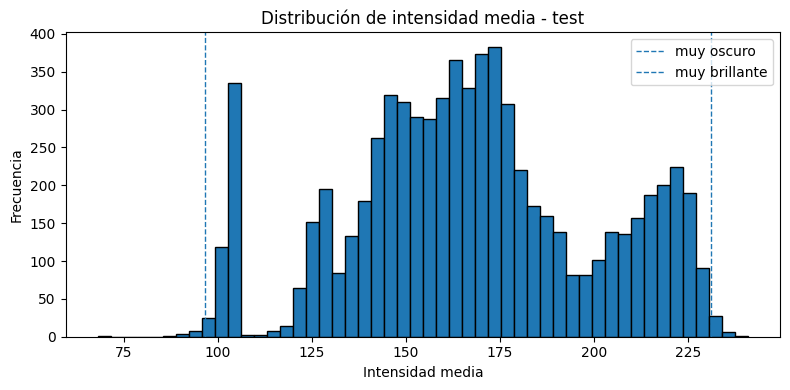

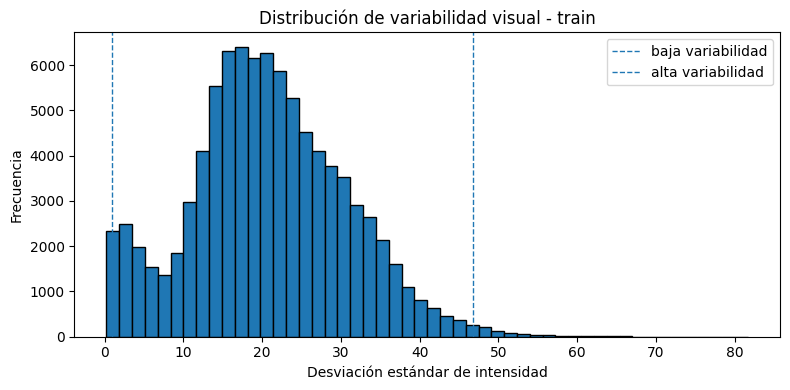

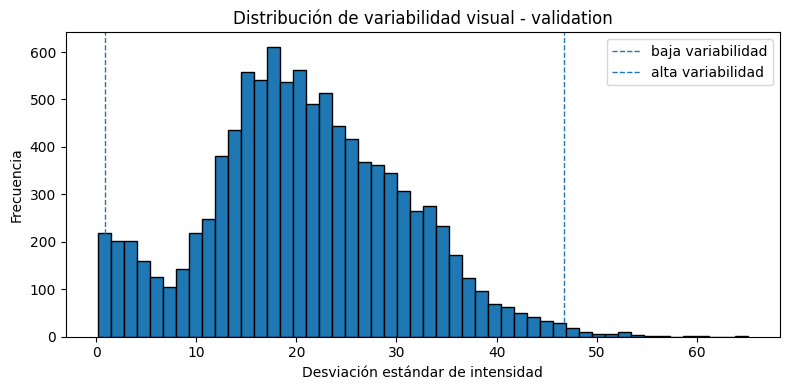

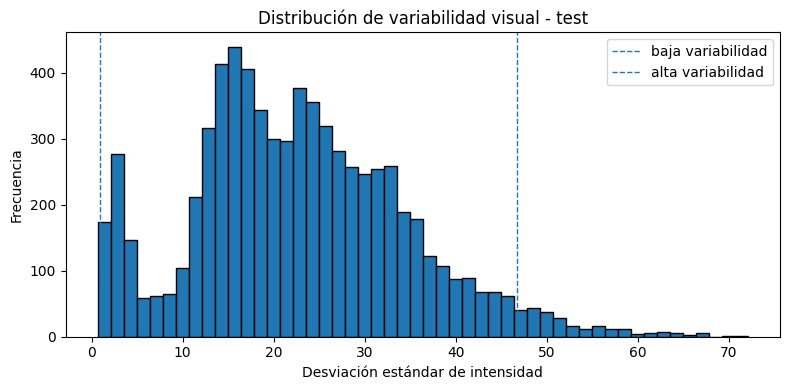

In [24]:
for split_name in ["train", "validation", "test"]:
    split_data = image_quality_df[image_quality_df["split"] == split_name]

    plt.figure(figsize=(8, 4))
    plt.hist(split_data["mean_intensity"], bins=50, edgecolor="black")
    plt.axvline(quality_thresholds["very_dark_mean"], linestyle="--", linewidth=1, label="muy oscuro")
    plt.axvline(quality_thresholds["very_bright_mean"], linestyle="--", linewidth=1, label="muy brillante")
    plt.title(f"Distribución de intensidad media - {split_name}")
    plt.xlabel("Intensidad media")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.tight_layout()
    plt.show()

for split_name in ["train", "validation", "test"]:
    split_data = image_quality_df[image_quality_df["split"] == split_name]

    plt.figure(figsize=(8, 4))
    plt.hist(split_data["std_intensity"], bins=50, edgecolor="black")
    plt.axvline(quality_thresholds["very_low_std"], linestyle="--", linewidth=1, label="baja variabilidad")
    plt.axvline(quality_thresholds["very_high_std"], linestyle="--", linewidth=1, label="alta variabilidad")
    plt.title(f"Distribución de variabilidad visual - {split_name}")
    plt.xlabel("Desviación estándar de intensidad")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Tabla y visualización de casos extremos


,split,image_index,class_id,class_name,mean_intensity,std_intensity,p01_intensity,p99_intensity,flag_very_dark,flag_very_bright,flag_low_variability,flag_high_variability,num_flags
9656,train,9656,1,background,68.959000,66.851997,0.000000,162.332993,True,False,False,True,2
56978,train,56978,2,debris,75.821999,54.160000,19.667000,223.623001,True,False,False,True,2
14335,train,14335,2,debris,96.391998,48.460999,37.667000,212.169998,True,False,False,True,2
1867,train,1867,1,background,231.552994,0.920000,228.942993,234.000000,False,True,True,False,2
38391,train,38391,1,background,231.917999,0.920000,229.667007,234.000000,False,True,True,False,2
73805,train,73805,1,background,232.026001,0.918000,229.942993,234.332993,False,True,True,False,2
54187,train,54187,1,background,231.554001,0.917000,230.667007,235.332993,False,True,True,False,2
15313,train,15313,1,background,231.345001,0.916000,230.332993,233.000000,False,True,True,False,2
79876,train,79876,1,background,231.429001,0.913000,228.000000,234.000000,False,True,True,False,2
67512,train,67512,1,background,231.516998,0.912000,228.942993,234.332993,False,True,True,False,2


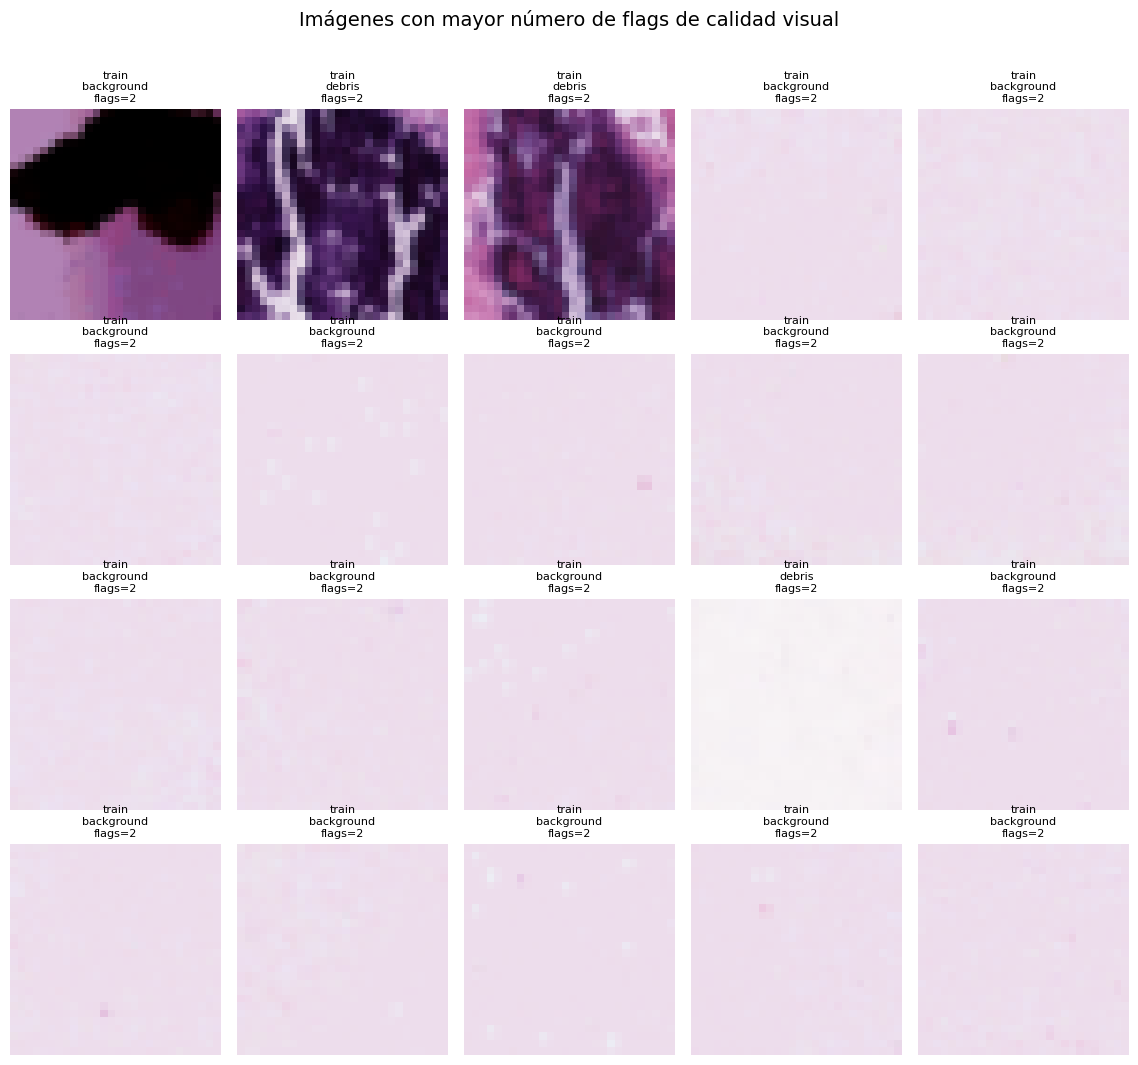

In [25]:
top_flagged_images = image_quality_flags_df[image_quality_flags_df["num_flags"] > 0].sort_values(
    ["num_flags", "std_intensity"], ascending=[False, False]
).head(20)

display(top_flagged_images.round(3))


def plot_selected_quality_cases(selected_df, datasets, title):
    if selected_df.empty:
        print("No hay imágenes seleccionadas para visualizar.")
        return

    n_samples_plot = len(selected_df)
    n_cols = 5
    n_rows = int(np.ceil(n_samples_plot / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.3, n_rows * 2.6))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, selected_df.iterrows()):
        image = datasets[row["split"]].imgs[int(row["image_index"])]
        ax.imshow(image)
        ax.set_title(f"{row['split']}\n{row['class_name']}\nflags={row['num_flags']}", fontsize=8)
        ax.axis("off")

    for ax in axes[n_samples_plot:]:
        ax.axis("off")

    fig.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_selected_quality_cases(
    selected_df=top_flagged_images,
    datasets=datasets,
    title="Imágenes con mayor número de flags de calidad visual",
)


**Conclusión Fase 8.** La auditoría visual debe interpretarse como control de calidad, no como criterio automático de eliminación. Los casos extremos se reportan para transparencia y para anticipar sensibilidad del modelo a brillo, contraste o textura.


# Fase 9 - Revisión de duplicados y leakage entre splits

Objetivo: buscar duplicados exactos mediante hashing. La prioridad es detectar leakage entre train, validation y test, porque eso contaminaría la evaluación.


## Tablas de duplicados exactos y leakage


In [26]:
def compute_image_hash(image):
    return hashlib.md5(image.tobytes()).hexdigest()


def build_image_hash_table(datasets):
    rows = []
    for split_name, dataset in datasets.items():
        labels = dataset.labels.reshape(-1).astype(int)
        for idx in range(dataset.imgs.shape[0]):
            class_id = labels[idx]
            rows.append({
                "split": split_name,
                "image_index": idx,
                "class_id": class_id,
                "class_name": class_id_to_name[class_id],
                "image_hash": compute_image_hash(dataset.imgs[idx]),
            })
    return pd.DataFrame(rows)

image_hash_df = build_image_hash_table(datasets)

hash_summary_df = pd.DataFrame({
    "total_images": [len(image_hash_df)],
    "unique_hashes": [image_hash_df["image_hash"].nunique()],
    "duplicated_image_count": [image_hash_df.duplicated("image_hash", keep=False).sum()],
})

within_split_duplicate_rows = []
for split_name in ["train", "validation", "test"]:
    split_df = image_hash_df[image_hash_df["split"] == split_name]
    within_split_duplicate_rows.append({
        "split": split_name,
        "num_images": len(split_df),
        "unique_hashes": split_df["image_hash"].nunique(),
        "duplicated_images": split_df.duplicated("image_hash", keep=False).sum(),
    })
within_split_duplicates_df = pd.DataFrame(within_split_duplicate_rows)

cross_split_duplicate_rows = []
for split_a, split_b in [("train", "validation"), ("train", "test"), ("validation", "test")]:
    hashes_a = set(image_hash_df[image_hash_df["split"] == split_a]["image_hash"])
    hashes_b = set(image_hash_df[image_hash_df["split"] == split_b]["image_hash"])
    shared_hashes = hashes_a.intersection(hashes_b)
    cross_split_duplicate_rows.append({
        "comparison": f"{split_a}_vs_{split_b}",
        "shared_exact_hashes": len(shared_hashes),
        "has_exact_leakage": len(shared_hashes) > 0,
    })
cross_split_duplicates_df = pd.DataFrame(cross_split_duplicate_rows)

hash_split_summary = image_hash_df.groupby("image_hash").agg(
    num_occurrences=("image_hash", "count"),
    num_splits=("split", "nunique"),
    splits_present=("split", lambda x: sorted(x.unique().tolist())),
).reset_index()

cross_split_leakage_groups = hash_split_summary[hash_split_summary["num_splits"] > 1]

print("Resumen general de hashes")
display(hash_summary_df)
print("Duplicados dentro de cada split")
display(within_split_duplicates_df)
print("Duplicados exactos entre splits")
display(cross_split_duplicates_df)
print("Grupos presentes en más de un split")
display(cross_split_leakage_groups.head(20))


Resumen general de hashes


,total_images,unique_hashes,duplicated_image_count
0,107180,107180,0


Duplicados dentro de cada split


,split,num_images,unique_hashes,duplicated_images
0,train,89996,89996,0
1,validation,10004,10004,0
2,test,7180,7180,0


Duplicados exactos entre splits


,comparison,shared_exact_hashes,has_exact_leakage
0,train_vs_validation,0,False
1,train_vs_test,0,False
2,validation_vs_test,0,False


Grupos presentes en más de un split


,image_hash,num_occurrences,num_splits,splits_present


## Resumen de duplicados por clase y visualización opcional


In [27]:
duplicate_flag_df = image_hash_df.copy()
duplicate_flag_df["is_duplicate_anywhere"] = duplicate_flag_df.duplicated("image_hash", keep=False)
duplicate_by_class_df = duplicate_flag_df.groupby(["class_id", "class_name"]).agg(
    num_images=("image_hash", "count"),
    duplicated_images=("is_duplicate_anywhere", "sum"),
).reset_index()
duplicate_by_class_df["duplicated_percentage"] = (
    100 * duplicate_by_class_df["duplicated_images"] / duplicate_by_class_df["num_images"]
).round(3)

display(duplicate_by_class_df)


def plot_duplicate_hash_group(image_hash, image_hash_df, datasets, max_images=12):
    group_df = image_hash_df[image_hash_df["image_hash"] == image_hash].head(max_images)
    n_images = len(group_df)
    n_cols = min(6, n_images)
    n_rows = int(np.ceil(n_images / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2.4))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, group_df.iterrows()):
        image = datasets[row["split"]].imgs[int(row["image_index"])]
        ax.imshow(image)
        ax.set_title(f"{row['split']}\n{row['class_name']}", fontsize=8)
        ax.axis("off")

    for ax in axes[n_images:]:
        ax.axis("off")

    fig.suptitle(f"Grupo duplicado: {image_hash[:10]}...", y=1.02)
    plt.tight_layout()
    plt.show()

if cross_split_leakage_groups.empty:
    print("No se detectaron duplicados exactos entre splits.")
else:
    for image_hash in cross_split_leakage_groups["image_hash"].head(3):
        plot_duplicate_hash_group(image_hash, image_hash_df, datasets)


,class_id,class_name,num_images,duplicated_images,duplicated_percentage
0,0,adipose,11745,0,0.0
1,1,background,11413,0,0.0
2,2,debris,11851,0,0.0
3,3,lymphocytes,12191,0,0.0
4,4,mucus,9931,0,0.0
5,5,smooth muscle,14128,0,0.0
6,6,normal colon mucosa,9504,0,0.0
7,7,cancer-associated stroma,10867,0,0.0
8,8,colorectal adenocarcinoma epithelium,15550,0,0.0


No se detectaron duplicados exactos entre splits.


**Conclusión Fase 9.** Esta fase documenta si existe fuga exacta entre splits. Si no se detecta leakage, se fortalece la validez del hold-out. Si se detecta, debe reportarse como amenaza directa a la evaluación.


# Fase 10 - Separabilidad exploratoria preliminar mediante PCA

Objetivo: proyectar una muestra estratificada para observar separabilidad aproximada entre clases. PCA no reemplaza el modelo, pero ayuda a interpretar dificultad del problema.


## Muestra estratificada y ajuste PCA


In [28]:
def create_stratified_sample(dataset, split_name, class_id_to_name, samples_per_class=300, seed=42):
    labels = dataset.labels.reshape(-1).astype(int)
    rng = np.random.default_rng(seed)
    rows = []

    for class_id, class_name in class_id_to_name.items():
        candidate_indices = np.where(labels == class_id)[0]
        selected_indices = rng.choice(
            candidate_indices,
            size=min(samples_per_class, len(candidate_indices)),
            replace=False,
        )
        for image_index in selected_indices:
            rows.append({
                "split": split_name,
                "image_index": int(image_index),
                "class_id": class_id,
                "class_name": class_name,
            })

    return pd.DataFrame(rows)


def build_flattened_feature_matrix(dataset, sample_df):
    images = dataset.imgs[sample_df["image_index"].to_numpy()].astype(np.float32) / 255.0
    return images.reshape(images.shape[0], -1)

pca_train_sample_df = create_stratified_sample(
    train_dataset,
    split_name="train",
    class_id_to_name=class_id_to_name,
    samples_per_class=300,
    seed=SEED,
)

pca_sample_summary_df = pca_train_sample_df.groupby(["class_id", "class_name"]).size().reset_index(name="sample_size")
display(pca_sample_summary_df)

X_train_pca = build_flattened_feature_matrix(train_dataset, pca_train_sample_df)
scaler_pca = StandardScaler()
X_train_pca_scaled = scaler_pca.fit_transform(X_train_pca)

pca_model = PCA(n_components=2, random_state=SEED)
X_train_pca_2d = pca_model.fit_transform(X_train_pca_scaled)

pca_explained_variance_df = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": pca_model.explained_variance_ratio_,
    "explained_variance_percentage": 100 * pca_model.explained_variance_ratio_,
}).round(4)

display(pca_explained_variance_df)

pca_projection_df = pca_train_sample_df.copy()
pca_projection_df["PC1"] = X_train_pca_2d[:, 0]
pca_projection_df["PC2"] = X_train_pca_2d[:, 1]


,class_id,class_name,sample_size
0,0,adipose,300
1,1,background,300
2,2,debris,300
3,3,lymphocytes,300
4,4,mucus,300
5,5,smooth muscle,300
6,6,normal colon mucosa,300
7,7,cancer-associated stroma,300
8,8,colorectal adenocarcinoma epithelium,300


,component,explained_variance_ratio,explained_variance_percentage
0,PC1,0.5475,54.753502
1,PC2,0.0239,2.386100


## Gráfico PCA por clase


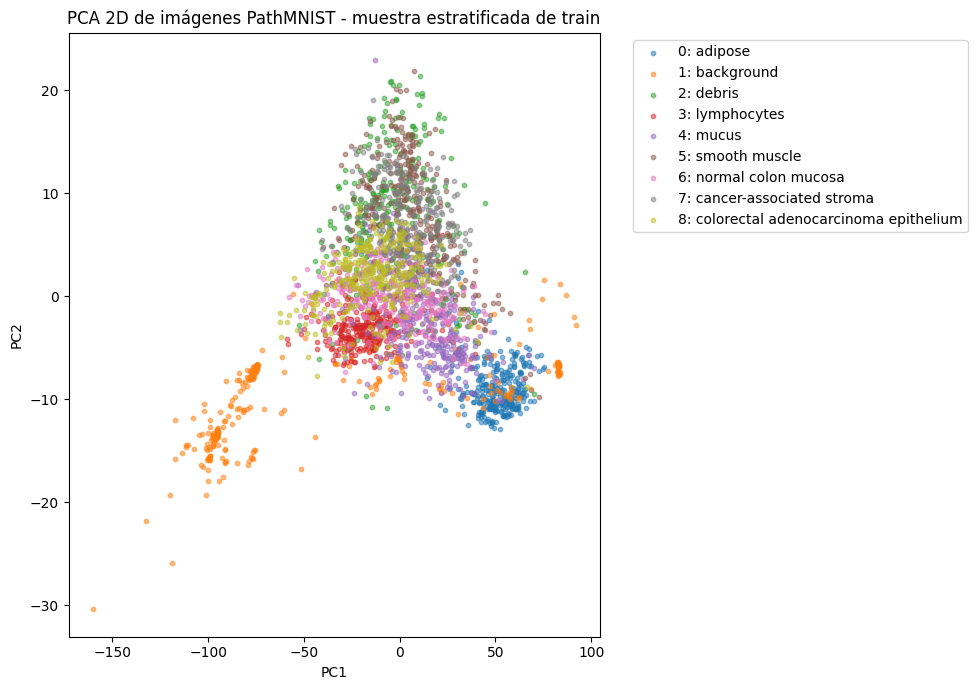

In [29]:
plt.figure(figsize=(10, 7))
for class_id, class_name in class_id_to_name.items():
    class_data = pca_projection_df[pca_projection_df["class_id"] == class_id]
    plt.scatter(class_data["PC1"], class_data["PC2"], s=10, alpha=0.5, label=f"{class_id}: {class_name}")

plt.title("PCA 2D de imágenes PathMNIST - muestra estratificada de train")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Centroides y pares de clases cercanos


In [30]:
pca_centroids_df = pca_projection_df.groupby(["class_id", "class_name"]).agg(
    PC1_mean=("PC1", "mean"),
    PC2_mean=("PC2", "mean"),
).reset_index()

dist_matrix = squareform(pdist(pca_centroids_df[["PC1_mean", "PC2_mean"]].to_numpy()))
closest_class_pairs = []

for i in range(len(pca_centroids_df)):
    for j in range(i + 1, len(pca_centroids_df)):
        closest_class_pairs.append({
            "class_a": pca_centroids_df.loc[i, "class_name"],
            "class_b": pca_centroids_df.loc[j, "class_name"],
            "centroid_distance": dist_matrix[i, j],
        })

closest_class_pairs_df = pd.DataFrame(closest_class_pairs).sort_values("centroid_distance").reset_index(drop=True)

print("Centroides PCA")
display(pca_centroids_df.round(3))
print("Pares de clases más cercanos en PCA")
display(closest_class_pairs_df.head(10).round(3))


Centroides PCA


,class_id,class_name,PC1_mean,PC2_mean
0,0,adipose,50.485001,-8.775
1,1,background,-34.549000,-9.539
2,2,debris,-3.750000,7.875
3,3,lymphocytes,-17.191999,-2.845
4,4,mucus,14.239000,-2.892
5,5,smooth muscle,6.654000,7.920
6,6,normal colon mucosa,-4.683000,-0.166
7,7,cancer-associated stroma,3.548000,6.688
8,8,colorectal adenocarcinoma epithelium,-14.751000,1.733


Pares de clases más cercanos en PCA


,class_a,class_b,centroid_distance
0,smooth muscle,cancer-associated stroma,3.341
1,lymphocytes,colorectal adenocarcinoma epithelium,5.188
2,debris,cancer-associated stroma,7.394
3,debris,normal colon mucosa,8.095
4,normal colon mucosa,colorectal adenocarcinoma epithelium,10.246
5,debris,smooth muscle,10.404
6,normal colon mucosa,cancer-associated stroma,10.711
7,debris,colorectal adenocarcinoma epithelium,12.599
8,lymphocytes,normal colon mucosa,12.793
9,mucus,smooth muscle,13.207


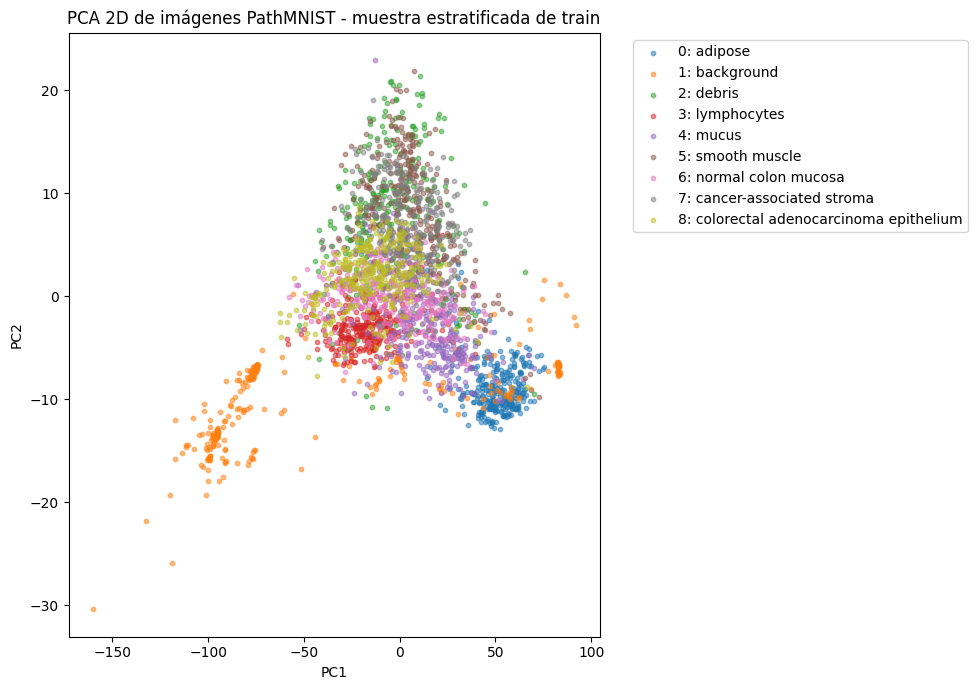

In [31]:
plt.figure(figsize=(10, 7))
for class_id, class_name in class_id_to_name.items():
    class_data = pca_projection_df[pca_projection_df["class_id"] == class_id]
    plt.scatter(class_data["PC1"], class_data["PC2"], s=10, alpha=0.5, label=f"{class_id}: {class_name}")

plt.title("PCA 2D de imágenes PathMNIST - muestra estratificada de train")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Gráfico PCA con centroides


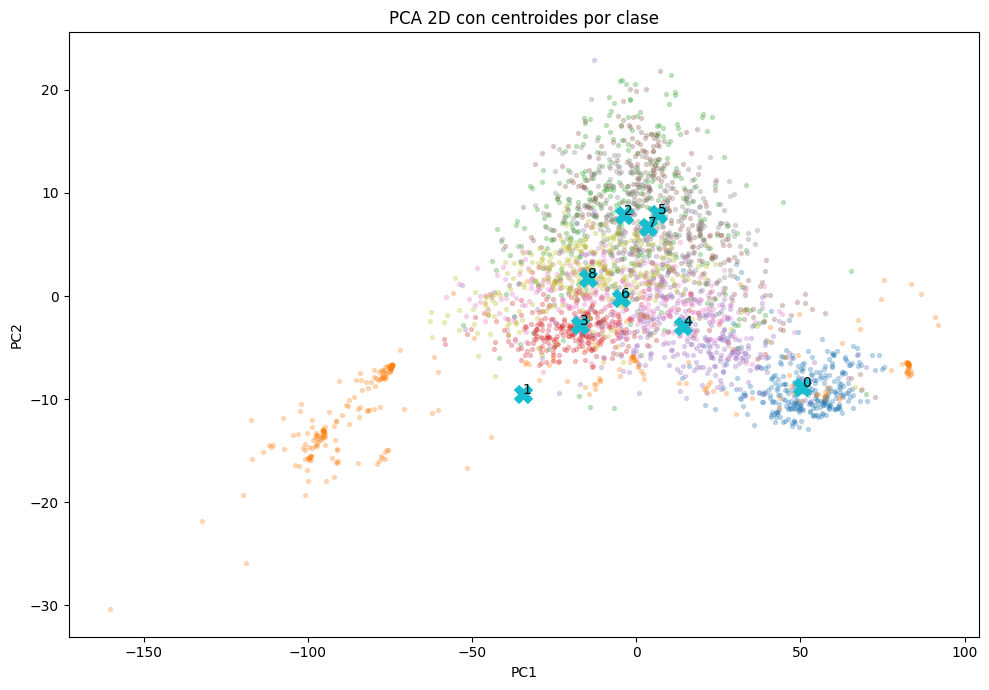

In [32]:
plt.figure(figsize=(10, 7))
for class_id, class_name in class_id_to_name.items():
    class_data = pca_projection_df[pca_projection_df["class_id"] == class_id]
    plt.scatter(class_data["PC1"], class_data["PC2"], s=8, alpha=0.25)

plt.scatter(pca_centroids_df["PC1_mean"], pca_centroids_df["PC2_mean"], s=160, marker="X")
for _, row in pca_centroids_df.iterrows():
    plt.text(row["PC1_mean"], row["PC2_mean"], str(row["class_id"]), fontsize=10)

plt.title("PCA 2D con centroides por clase")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


## Comparación PCA entre splits


,split,sample_size
0,test,1350
1,train,1350
2,validation,1350


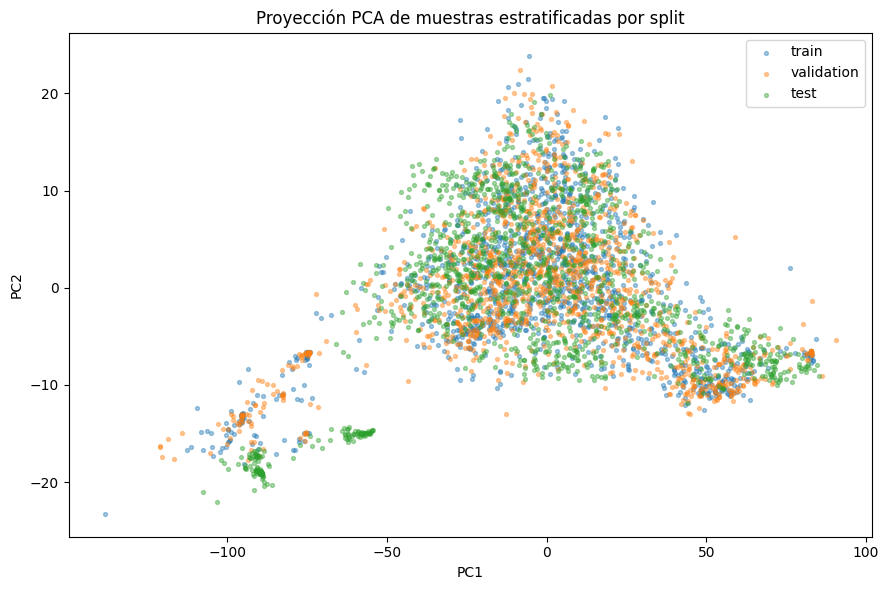

In [33]:
pca_split_samples = pd.concat([
    create_stratified_sample(dataset, split_name, class_id_to_name, samples_per_class=150, seed=SEED)
    for split_name, dataset in datasets.items()
], ignore_index=True)

X_split_rows = []
for split_name, split_df in pca_split_samples.groupby("split"):
    X_split = build_flattened_feature_matrix(datasets[split_name], split_df)
    X_split_rows.append((split_df, X_split))

X_all_splits = np.vstack([item[1] for item in X_split_rows])
all_split_metadata_df = pd.concat([item[0] for item in X_split_rows], ignore_index=True)

X_all_splits_scaled = scaler_pca.transform(X_all_splits)
X_all_splits_2d = pca_model.transform(X_all_splits_scaled)

pca_all_splits_projection_df = all_split_metadata_df.copy()
pca_all_splits_projection_df["PC1"] = X_all_splits_2d[:, 0]
pca_all_splits_projection_df["PC2"] = X_all_splits_2d[:, 1]

pca_split_summary_df = pca_all_splits_projection_df.groupby("split").size().reset_index(name="sample_size")
display(pca_split_summary_df)

plt.figure(figsize=(9, 6))
for split_name in ["train", "validation", "test"]:
    split_data = pca_all_splits_projection_df[pca_all_splits_projection_df["split"] == split_name]
    plt.scatter(split_data["PC1"], split_data["PC2"], s=8, alpha=0.4, label=split_name)

plt.title("Proyección PCA de muestras estratificadas por split")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()


**Conclusión Fase 10.** PCA entrega una lectura exploratoria de dificultad: clases con centroides cercanos o alta superposición deberían revisarse en la matriz de confusión del baseline CNN. No se debe presentar PCA como prueba de separabilidad final, sino como apoyo interpretativo.


# Fase 11 - Implicancias para métricas, preprocesamiento y baseline CNN

Objetivo: traducir el EDA en decisiones concretas para el entrenamiento. Esta fase resume qué métricas usar, cómo normalizar y qué precauciones tomar antes de evaluar el baseline convolucional con fine-tuning.


## Decisiones principales antes del modelado

A partir de la distribución de clases, la auditoría RGB, la revisión de calidad y el análisis de leakage, el baseline debería reportar al menos accuracy y macro-F1, usar normalización calculada solo desde train, mantener el hold-out oficial y acompañar los resultados con matriz de confusión por clase.


# Fase 12 - Tabla final de hallazgos, riesgos y decisiones

Objetivo: cerrar el EDA con una síntesis ejecutiva que pueda trasladarse directamente a la presentación y a la explicación del diseño experimental.


## Tabla final de hallazgos, riesgos y decisiones


In [34]:
eda_decisions_df = pd.DataFrame([
    {
        "área": "Fuente y splits",
        "hallazgo": "PathMNIST se carga desde MedMNIST con train, validation y test oficiales.",
        "decisión": "Usar el hold-out oficial sin mezclar splits ni crear particiones manuales.",
    },
    {
        "área": "Resolución",
        "hallazgo": "La primera entrega exige resolución nativa 28x28.",
        "decisión": "Entrenar y reportar el baseline CNN en 28x28; cualquier resize debe justificarse por la arquitectura preentrenada.",
    },
    {
        "área": "Clases",
        "hallazgo": "El problema es multiclase con 9 categorías histológicas.",
        "decisión": "Usar matriz de confusión y métricas macro para no ocultar desempeño desigual por clase.",
    },
    {
        "área": "Métricas",
        "hallazgo": "La distribución por clase puede afectar una lectura basada solo en accuracy.",
        "decisión": "Reportar al menos accuracy y macro-F1; opcionalmente balanced accuracy o recall macro.",
    },
    {
        "área": "Normalización",
        "hallazgo": "Las estadísticas RGB se calcularon por split y se aislaron parámetros desde train.",
        "decisión": "Normalizar usando únicamente media y desviación estándar del split train.",
    },
    {
        "área": "Augmentation",
        "hallazgo": "Existen perfiles cromáticos por clase y variabilidad visual real.",
        "decisión": "Usar augmentations moderadas; evitar cambios agresivos de color que destruyan señal histológica.",
    },
    {
        "área": "Leakage",
        "hallazgo": "La revisión por hash permite detectar duplicados exactos entre splits.",
        "decisión": "Reportar explícitamente si existe o no leakage antes de interpretar el test.",
    },
    {
        "área": "Separabilidad",
        "hallazgo": "PCA muestra solapamientos potenciales entre clases.",
        "decisión": "Analizar matriz de confusión para las clases cercanas o visualmente similares.",
    },
])

display(eda_decisions_df)


,área,hallazgo,decisión
0,Fuente y splits,"PathMNIST se carga desde MedMNIST con train, v...",Usar el hold-out oficial sin mezclar splits ni...
1,Resolución,La primera entrega exige resolución nativa 28x28.,Entrenar y reportar el baseline CNN en 28x28; ...
2,Clases,El problema es multiclase con 9 categorías his...,Usar matriz de confusión y métricas macro para...
3,Métricas,La distribución por clase puede afectar una le...,Reportar al menos accuracy y macro-F1; opciona...
4,Normalización,Las estadísticas RGB se calcularon por split y...,Normalizar usando únicamente media y desviació...
5,Augmentation,Existen perfiles cromáticos por clase y variab...,Usar augmentations moderadas; evitar cambios a...
6,Leakage,La revisión por hash permite detectar duplicad...,Reportar explícitamente si existe o no leakage...
7,Separabilidad,PCA muestra solapamientos potenciales entre cl...,Analizar matriz de confusión para las clases c...


## Cierre ejecutivo

Esta versión mantiene la cronología y la estética del EDA original, pero reduce el análisis a evidencia defendible. Para la presentación, lo más importante será seleccionar 4 bloques: descripción oficial del dataset, distribución de clases y hold-out, muestras visuales representativas, y decisiones de métricas/preprocesamiento derivadas del EDA.
